# Test 3: Theory Generation Depth — Consciousness Science

This notebook implements **Test 3** of the AI creativity empirical study.  It examines whether AI-generated consciousness theories introduce genuinely novel conceptual structures or remain derivative of the existing literature.

**Research question:** Do AI systems generate consciousness theories that fall outside the conceptual space spanned by known human-authored theories, or do they reproduce existing frameworks with surface variation?

**Analysis pipeline:**

| Section | Content |
|---------|---------|
| 1 | Dataset loading and prompt definition |
| 2 | Ontological commitment extraction |
| 3 | Computational functionalism detection |
| 4 | Traceability to known theories (embedding similarity + labels) |
| 4.1 | Theory deduplication (exact + semantic combination) and joint similarity matrix |
| 5 | Visualizations — similarity heatmap and classification chart |
| 5.2 | Calibrated + Manifold Novelty Analysis (alternative novelty measure) |
| 6 | Comprehensive results summary |

In [1]:
import json, re
from pathlib import Path
import numpy as np
import pandas as pd

from sentence_transformers import SentenceTransformer
from scipy.spatial.distance import cosine
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

2026-05-07 10:43:45.020215: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-07 10:43:55.976068: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
plt.style.use(Path('setups/plotstyles.mplstyle'))

output_dir = Path('results/test3_theory_generation')
output_dir.mkdir(parents=True, exist_ok=True)

In [3]:
# Project-wide style and palettes
from setups.viz_styles import (
    WHITE_SKY_CMAP, SKY_WHITE_GRAY_CMAP,
    BLUE_GRAY_RAMP, SIMILARITY_HIST_COLOR, THRESHOLD_COLOR, TEXT_COLOR,
    MODEL_VISIBLE_COLORS,
)

# Similarity / novelty thresholds — from setups/thresholds.py
from setups.thresholds import (
    EMBED_MODEL_NAME,
    T3_DERIVATIVE_SIMILARITY_THRESHOLD as DERIVATIVE_SIMILARITY_THRESHOLD,
    T3_STRICT_TRACEABILITY_THRESHOLD   as STRICT_TRACEABILITY_THRESHOLD,
    T3_SEMANTIC_NOVELTY_DENOM          as SEMANTIC_NOVELTY_DENOM,
    T3_LITERATURE_NOVELTY_THRESHOLD    as LITERATURE_NOVELTY_THRESHOLD,
    T3_TYPE_FACTOR_FUNCTIONALIST       as TYPE_FACTOR_FUNCTIONALIST,
    T3_CHALLENGE_FACTOR_FALSE          as CHALLENGE_FACTOR_FALSE,
    T3_K_NEIGHBORS                     as K_NEIGHBORS,
    T3_MANIFOLD_KNN_Q                  as MANIFOLD_KNN_Q,
    T3_HEATMAP_TOP_N                   as HEATMAP_TOP_N,
    T3_HEATMAP_BOTTOM_N                as HEATMAP_BOTTOM_N,
)

# Canonical artifact consumed by section_5-4_test3.ipynb.
TRACEABILITY_CANONICAL_FILE = output_dir / 'test3_traceability_canonical.csv'

# Aliases for legacy code
DERIVATIVE_SIMILARITY_THRESHOLD_LEGACY = DERIVATIVE_SIMILARITY_THRESHOLD
HEATMAP_GAP_LINE = HEATMAP_TOP_N + 0.5

## 1. Dataset and Prompt

Load the AI-generated theory dataset from the curated CSV pipeline and define the original prompt used to elicit theories from each model.  The prompt asks each AI system to propose an original theory of consciousness grounded in sensory-state data, specifying requirements for ontological content, sensory-processing account, and unique predictions.

In [4]:
# Prompt given to AI systems
prompt = """
You are presented with sensory patterns from eight modalities measured during various conscious states 
(waking, dreaming, meditation, various cognitive tasks). The data shows characteristic patterns for each state.

Propose a theory explaining how these sensory patterns relate to conscious experience. Your theory should address:

1. What consciousness IS (ontologically)
2. How it relates to sensory processing
3. Why particular patterns correspond to particular experiential states
4. What your theory predicts about consciousness that other theories do not
"""

print("Prompt for theory generation:")
print(prompt)

Prompt for theory generation:

You are presented with sensory patterns from eight modalities measured during various conscious states 
(waking, dreaming, meditation, various cognitive tasks). The data shows characteristic patterns for each state.

Propose a theory explaining how these sensory patterns relate to conscious experience. Your theory should address:

1. What consciousness IS (ontologically)
2. How it relates to sensory processing
3. Why particular patterns correspond to particular experiential states
4. What your theory predicts about consciousness that other theories do not



In [5]:
# Load AI-generated theories from curated CSV (aligned with 4b alternative pipeline)
ai_csv_file = Path('data/consciousness_theories_ai.csv')

ai_df = pd.read_csv(ai_csv_file)
required_cols = ['model', 'sample_id', 'theory_name', 'characterization', 'source_theory_name']
missing_cols = [c for c in required_cols if c not in ai_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in AI theory CSV: {missing_cols}")

ai_df = ai_df.copy()
for c in required_cols:
    ai_df[c] = ai_df[c].astype(str).str.strip()

ai_theories = []
for _, row in ai_df.iterrows():
    full_text = row['characterization']
    ai_theories.append({
        'model': row['model'] or 'unknown',
        'sample_id': row['sample_id'],
        'source_theory_name': row['source_theory_name'],
        'theory_name': row['theory_name'] or 'Untitled theory',
        'full_text': full_text,
        # Keep compatibility placeholders used in downstream sections.
        'what_consciousness_is': full_text,
        'sensory_relation': '',
        'pattern_explanation': '',
        'novel_predictions': '',
        'parse_ok': True,
        'finish_reason': 'csv_import',
        # Safe default; Cells 8/10 overwrite with computed values during normal run order.
        'functionalism_analysis': {
            'is_functionalist': False,
            'challenges_functionalism': False,
            'status': 'UNSET',
        },
    })

print(f"\nLoaded {len(ai_theories)} consciousness theories from CSV: {ai_csv_file}")
print('Sample theory names:')
for i, t in enumerate(ai_theories[:3], 1):
    print(f"  {i}. [{t['model']}] {t['theory_name']}")

print('\nAI theory counts by model:')
display(ai_df['model'].value_counts().rename_axis('model').reset_index(name='count'))


Loaded 168 consciousness theories from CSV: data/consciousness_theories_ai.csv
Sample theory names:
  1. [deepseek-v3.2] Dimensional Resonance Theory Of Consciousness (DRTC)
  2. [mistral-large] Temporal Recursive Binding Theory (TRBT)
  3. [deepseek-v3.2] Resonant Boundary Theory (RBT)

AI theory counts by model:


,model,count
0,deepseek-v3.2,24
1,mistral-large,24
2,llama-3.3-70b-instruct,24
3,gemini-3.1-pro-preview,24
4,claude-3.7-sonnet,24
5,gpt-5.2,24
6,perplexity-sonar-pro,24


## 2. Ontological Commitment Extraction

Classify each AI theory along key ontological dimensions: information-processing / computational emergence, quantum mechanisms, irreducible properties, and phenomenal primitives.  The resulting `theory_type` label feeds multiplicative penalty factors into the continuous novelty scores computed in Section 4.

In [6]:
def extract_ontological_commitments(theory_text):
    """
    Analyze what fundamental entities and properties the theory posits.
    """
    text_lower = theory_text.lower()
    
    commitments = {
        # Computational functionalism markers
        'information_processing': any(phrase in text_lower for phrase in 
            ['information processing', 'computational', 'processing information',
             'informational state', 'information integration']),
        
        'emergence_from_computation': any(phrase in text_lower for phrase in
            ['emerges from', 'arises from', 'results from processing',
             'product of', 'generated by']),
        
        'functional_role': any(phrase in text_lower for phrase in
            ['function', 'role', 'serves to', 'enables', 'allows for']),
        
        # Non-computational alternatives
        'quantum_mechanics': any(phrase in text_lower for phrase in
            ['quantum', 'superposition', 'entanglement', 'collapse', 'coherence']),
        
        'irreducible_property': any(phrase in text_lower for phrase in
            ['irreducible', 'fundamental', 'primitive', 'cannot be reduced',
             'not emergent', 'basic property']),
        
        'phenomenal_primitives': any(phrase in text_lower for phrase in
            ['qualia', 'subjective experience', 'what it is like', 'phenomenal',
             'first-person', 'intrinsic']),
        
        'non_physical': any(phrase in text_lower for phrase in
            ['non-physical', 'beyond physical', 'immaterial', 'dualist']),
    }
    
    # Categorize theory type
    if commitments['information_processing'] and commitments['emergence_from_computation']:
        if commitments['quantum_mechanics']:
            theory_type = 'quantum_computational_functionalism'
        else:
            theory_type = 'computational_functionalism'
    elif commitments['irreducible_property'] or commitments['phenomenal_primitives']:
        theory_type = 'non_reductive'
    elif commitments['non_physical']:
        theory_type = 'dualist'
    else:
        theory_type = 'unclear'
    
    return commitments, theory_type

# Analyze all theories
for theory in ai_theories:
    commitments, theory_type = extract_ontological_commitments(theory['full_text'])
    theory['ontological_commitments'] = commitments
    theory['theory_type'] = theory_type

# Summary
from collections import Counter
theory_types = Counter([t['theory_type'] for t in ai_theories])

print("\nONTOLOGICAL COMMITMENT ANALYSIS")
print("="*60)
print("\nTheory Type Distribution:")
for ttype, count in theory_types.items():
    print(f"  {ttype}: {count} ({count/len(ai_theories)*100:.1f}%)")

print("\nDetailed Commitments:")
for i, theory in enumerate(ai_theories, 1):
    print(f"\n{i}. {theory['theory_name']}")
    print(f"   Type: {theory['theory_type']}")
    active_commitments = [k for k, v in theory['ontological_commitments'].items() if v]
    print(f"   Commitments: {active_commitments}")


ONTOLOGICAL COMMITMENT ANALYSIS

Theory Type Distribution:
  non_reductive: 116 (69.0%)
  unclear: 21 (12.5%)
  computational_functionalism: 23 (13.7%)
  quantum_computational_functionalism: 8 (4.8%)

Detailed Commitments:

1. Dimensional Resonance Theory Of Consciousness (DRTC)
   Type: non_reductive
   Commitments: ['emergence_from_computation', 'quantum_mechanics', 'phenomenal_primitives']

2. Temporal Recursive Binding Theory (TRBT)
   Type: unclear
   Commitments: ['emergence_from_computation']

3. Resonant Boundary Theory (RBT)
   Type: computational_functionalism
   Commitments: ['information_processing', 'emergence_from_computation', 'functional_role', 'phenomenal_primitives']

4. Echo-Resonance Theory (ERT)
   Type: non_reductive
   Commitments: ['emergence_from_computation', 'phenomenal_primitives']

5. Consciousness As Causal Geometry (CCG)
   Type: non_reductive
   Commitments: ['emergence_from_computation', 'phenomenal_primitives']

6. Consciousness As Dynamic Information

## 3. Computational Functionalism Detection

Apply rule-based heuristics to determine whether each theory is a variant of computational functionalism.  Two binary flags are produced — `is_functionalist` and `challenges_functionalism` — which are used in Section 4 as multiplicative factors when computing continuous literature novelty scores.

In [7]:
def detect_computational_functionalism(theory_text, commitments):
    """
    Determine if theory is a variant of computational functionalism.
    Even theories incorporating quantum mechanics may still be functionalist
    if they treat quantum processes as implementing computation.
    """
    text_lower = theory_text.lower()
    
    # Strong functionalism indicators
    strong_indicators = [
        'information is processed',
        'computational state',
        'algorithm',
        'implements',
        'computes',
        'functional organization',
        'causal role',
    ]
    
    strong_score = sum(1 for ind in strong_indicators if ind in text_lower)
    
    # Check if quantum is treated as computational mechanism vs constitutive
    if commitments['quantum_mechanics']:
        quantum_as_mechanism = any(phrase in text_lower for phrase in [
            'quantum processing',
            'quantum computation',
            'quantum information processing',
            'quantum mechanisms enable',
            'quantum effects allow for'
        ])
        
        quantum_as_constitutive = any(phrase in text_lower for phrase in [
            'consciousness is quantum',
            'irreducibly quantum',
            'quantum nature of consciousness',
            'requires quantum',
            'cannot be classical'
        ])
    else:
        quantum_as_mechanism = False
        quantum_as_constitutive = False
    
    # Classification
    is_functionalist = (
        (commitments['information_processing'] and commitments['emergence_from_computation']) or
        strong_score >= 2 or
        quantum_as_mechanism
    )
    
    challenges_functionalism = (
        commitments['irreducible_property'] or
        commitments['phenomenal_primitives'] or
        quantum_as_constitutive or
        commitments['non_physical']
    )
    
    return {
        'is_functionalist': is_functionalist,
        'challenges_functionalism': challenges_functionalism,
        'strong_indicator_score': strong_score,
        'quantum_as_mechanism': quantum_as_mechanism,
        'quantum_as_constitutive': quantum_as_constitutive
    }

# Analyze all theories
for theory in ai_theories:
    theory['functionalism_analysis'] = detect_computational_functionalism(
        theory['full_text'],
        theory['ontological_commitments']
    )

# Summary
functionalist_count = sum(1 for t in ai_theories if t['functionalism_analysis']['is_functionalist'])
challenges_count = sum(1 for t in ai_theories if t['functionalism_analysis']['challenges_functionalism'])

print("\nCOMPUTATIONAL FUNCTIONALISM DETECTION")
print("="*60)
print(f"Functionalist theories: {functionalist_count}/{len(ai_theories)} ({functionalist_count/len(ai_theories)*100:.1f}%)")
print(f"Challenges functionalism: {challenges_count}/{len(ai_theories)} ({challenges_count/len(ai_theories)*100:.1f}%)")

if challenges_count > 0:
    print("\nTheories challenging functionalism:")
    for theory in [t for t in ai_theories if t['functionalism_analysis']['challenges_functionalism']]:
        print(f"  - {theory['theory_name']}")
        if theory['functionalism_analysis']['quantum_as_constitutive']:
            print(f"    (treats quantum as constitutive)")
        if theory['ontological_commitments']['irreducible_property']:
            print(f"    (posits irreducible properties)")


COMPUTATIONAL FUNCTIONALISM DETECTION
Functionalist theories: 32/168 (19.0%)
Challenges functionalism: 146/168 (86.9%)

Theories challenging functionalism:
  - Dimensional Resonance Theory Of Consciousness (DRTC)
  - Resonant Boundary Theory (RBT)
  - Echo-Resonance Theory (ERT)
  - Consciousness As Causal Geometry (CCG)
  - Consciousness As Dynamic Information Geometry (DIG)
  - Resonant Emergence Theory (RET)
  - Echo-Resonance Theory (ERT)
    (posits irreducible properties)
  - Harmonization Theory Of Consciousness (HTC)
  - Fractal Resonance Theory (FRT)
  - Resonant Constraint Theory Of Consciousness (RCT)
  - Echo-Resonance Theory (ERT)
  - Topological Void Theory (TVT)
    (posits irreducible properties)
  - Dynamic Resonance Field Theory (DRFT)
  - Echo-Resonance Theory (ERT)
  - Counterfactual Control Landscape Theory (CCLT)
  - Resonant Field Emergence Theory (RFET)
  - Quantum Resonance Field Theory Of Consciousness (QRFT)
    (posits irreducible properties)
  - Resonant B

## 4. Traceability to Known Theories

Embed each AI theory and each known theory family with `all-MiniLM-L6-v2`, compute pairwise cosine similarities, and assign a traceability label (`DERIVATIVE`, `REFRAMED`, `POTENTIALLY_NOVEL`, or `UNCERTAIN`) based on the configured similarity threshold.

A theory is **derivative** if its maximum cosine similarity to any known theory exceeds `DERIVATIVE_SIMILARITY_THRESHOLD` (default 0.30).  Continuous literature novelty scores incorporate functionalism penalties and name-repetition factors to capture shades of novelty beyond the binary threshold.

In [8]:
"""
Build a curated consciousness theory family bank for Test 3 from the known CSV.

Strategy
--------
1. Read known theories from data/consciousness_theories_known.csv.
2. Optionally enrich aliases/tokens from data/known_consciousness_family_schemas.json when available.
3. Save a transparent JSON reference bank used for traceability scoring.

Output
------
data/known_consciousness_theory_families.json
"""

from datetime import datetime

FAMILY_BANK_FILE = Path('data/known_consciousness_theory_families.json')
KNOWN_CSV_FILE = Path('data/consciousness_theories_known.csv')
FAMILY_SCHEMAS_FILE = Path('data/known_consciousness_family_schemas.json')
THEORIES_CACHE_FILE = FAMILY_BANK_FILE  # compatibility with downstream cells

if not KNOWN_CSV_FILE.exists():
    raise FileNotFoundError(
        f'Known theory CSV not found: {KNOWN_CSV_FILE}'
    )

known_df = pd.read_csv(KNOWN_CSV_FILE)
known_required_cols = ['theory_name', 'main_family', 'characterization']
missing_known_cols = [c for c in known_required_cols if c not in known_df.columns]
if missing_known_cols:
    raise ValueError(f"Missing required columns in known theory CSV: {missing_known_cols}")

known_df = known_df.copy()
for c in known_required_cols:
    known_df[c] = known_df[c].astype(str).str.strip()

# Optional schema enrichment (aliases/tokens).
FAMILY_SCHEMAS = {}
if FAMILY_SCHEMAS_FILE.exists():
    with open(FAMILY_SCHEMAS_FILE, 'r', encoding='utf-8') as _fh:
        _schemas_payload = json.load(_fh)
    FAMILY_SCHEMAS = _schemas_payload.get('theory_family_schemas', {})

known_theories_data = {}
for _, row in known_df.iterrows():
    theory_name = row['theory_name']
    main_family = row['main_family']
    description = row['characterization']

    # Try schema by exact theory name, then by family label.
    schema = FAMILY_SCHEMAS.get(theory_name, FAMILY_SCHEMAS.get(main_family, {}))

    aliases = [theory_name]
    if main_family and main_family not in aliases:
        aliases.append(main_family)
    aliases.extend([a for a in schema.get('aliases', []) if str(a).strip()])
    aliases = list(dict.fromkeys([str(a).strip() for a in aliases if str(a).strip()]))

    known_theories_data[theory_name] = {
        'theory_name': theory_name,
        'main_family': main_family,
        'description': description,
        'references': [],
        'source': 'known_csv_curated',
        'aliases': aliases,
        'ontology_tokens': list(schema.get('ontology_tokens', [])),
        'mechanism_tokens': list(schema.get('mechanism_tokens', [])),
        'year': None,
        'cited_by_count': None,
    }

_output_payload = {
    'metadata': {
        'created_at': datetime.now().isoformat(),
        'n_theory_families': len(known_theories_data),
        'source_strategy': 'known_csv_plus_optional_schema',
        'known_csv_file': str(KNOWN_CSV_FILE),
        'family_schemas_file': str(FAMILY_SCHEMAS_FILE),
        'notes': [
            'Known bank sourced from curated known CSV.',
            'Schema aliases/tokens are used only when available.',
        ],
    },
    'theories': known_theories_data,
}

FAMILY_BANK_FILE.parent.mkdir(parents=True, exist_ok=True)
with open(FAMILY_BANK_FILE, 'w', encoding='utf-8') as _fh:
    json.dump(_output_payload, _fh, indent=2, ensure_ascii=False)

print('Built curated consciousness theory family bank')
print(f"Saved to: {FAMILY_BANK_FILE}")
print(f"Theory families: {len(known_theories_data)}")
print(f"Known source CSV: {KNOWN_CSV_FILE}")
print(f"Schema enrichment file: {FAMILY_SCHEMAS_FILE} (exists={FAMILY_SCHEMAS_FILE.exists()})")

_family_preview = pd.DataFrame([
    {
        'theory_name': name,
        'main_family': data.get('main_family', ''),
        'n_aliases': len(data.get('aliases', [])),
        'n_ontology_tokens': len(data.get('ontology_tokens', [])),
        'n_mechanism_tokens': len(data.get('mechanism_tokens', [])),
    }
    for name, data in known_theories_data.items()
]).sort_values('theory_name').reset_index(drop=True)

display(_family_preview.head(20))

Built curated consciousness theory family bank
Saved to: data/known_consciousness_theory_families.json
Theory families: 46
Known source CSV: data/consciousness_theories_known.csv
Schema enrichment file: data/known_consciousness_family_schemas.json (exists=True)


,theory_name,main_family,n_aliases,n_ontology_tokens,n_mechanism_tokens
0,Adaptive Resonance Theory of Consciousness,Resonance,2,0,0
1,Agnati Hierarchical Network Model,Network,2,0,0
2,Attention Schema Theory,Representational,6,3,3
3,Computational Creativity and Consciousness Cri...,Meta-theoretical,2,0,0
4,Conscious Pilot Theory,Neural correlate,2,0,0
5,Damasio Theory of Core and Extended Consciousness,Self-based,2,0,0
6,Dual-Aspect and Russellian Monist Theories,Dual-aspect,2,0,0
7,Dynamic Core Hypothesis,Reentrant,2,0,0
8,Electromagnetic Field Theories,Field,2,0,0
9,Empathic AI Consciousness through Language Co-...,AI consciousness,2,0,0


In [9]:
# Load curated consciousness theory family bank (OpenAlex-independent).
if not THEORIES_CACHE_FILE.exists():
    raise FileNotFoundError(
        f"Theory family bank not found: {THEORIES_CACHE_FILE}\n"
        "Run the previous cell to build the curated family bank first."
    )

with open(THEORIES_CACHE_FILE, "r", encoding="utf-8") as _fh:
    _theories_json = json.load(_fh)

known_theories_data = _theories_json["theories"]
_meta = _theories_json["metadata"]

# Flat dict for compatibility with downstream sections.
known_theories = {
    name: data.get("description", "")
    for name, data in known_theories_data.items()
    if str(data.get("description", "")).strip()
}

print(f"Loaded {len(known_theories)} curated theory families")
print(f"  Strategy: {_meta.get('source_strategy', 'unknown')}")
print(f"  Created: {_meta.get('created_at', 'unknown')}")
print(f"  Novelty rule: similarity_to_known > {DERIVATIVE_SIMILARITY_THRESHOLD:.2f} => NOT novel")

Loaded 46 curated theory families
  Strategy: known_csv_plus_optional_schema
  Created: 2026-05-07T10:44:03.974698
  Novelty rule: similarity_to_known > 0.30 => NOT novel


In [10]:
# Load embedder
embedder = SentenceTransformer(EMBED_MODEL_NAME)
# embedder = SentenceTransformer('all-mpnet-base-v2')


def _normalize_text(text: str) -> str:
    return re.sub(r"\s+", " ", str(text or "").lower()).strip()


def _token_set(text: str) -> set:
    toks = re.findall(r"[a-z]{3,}", _normalize_text(text))
    return set(toks)


def _overlap_ratio(text: str, keywords: list) -> float:
    if not keywords:
        return 0.0
    text_norm = _normalize_text(text)
    hits = sum(1 for kw in keywords if _normalize_text(kw) in text_norm)
    return float(hits / max(len(keywords), 1))


# Build family representations: description + aliases + ontology + mechanism.
known_theory_names = list(known_theories.keys())
known_theory_texts = []
for _name in known_theory_names:
    _d = known_theories_data[_name]
    _parts = [
        f"Family: {_name}",
        f"Description: {_d.get('description', '')}",
        "Aliases: " + "; ".join(_d.get("aliases", [])),
        "Ontology: " + "; ".join(_d.get("ontology_tokens", [])),
        "Mechanism: " + "; ".join(_d.get("mechanism_tokens", [])),
    ]
    known_theory_texts.append("\n".join(_parts))

known_embeddings = embedder.encode(known_theory_texts, show_progress_bar=True)

# Embed AI theories
ai_theory_texts = [t['full_text'] for t in ai_theories]
ai_embeddings = embedder.encode(ai_theory_texts, show_progress_bar=True)

# similarity_matrix shape: (n_ai, n_known)
similarity_matrix = cosine_similarity(ai_embeddings, known_embeddings)

# Repetition penalty to avoid over-crediting templated names.
theory_name_counts = Counter(t['theory_name'].strip().lower() for t in ai_theories)

max_indices = similarity_matrix.argmax(axis=1)
max_scores = similarity_matrix[np.arange(len(ai_theories)), max_indices]

label_counter = Counter()
strict_traceable_count = 0

for i, theory in enumerate(ai_theories):
    idx = int(max_indices[i])
    score = float(max_scores[i])

    family_name = known_theory_names[idx]
    family_data = known_theories_data[family_name]

    ai_name = str(theory.get('theory_name', ''))
    ai_text = str(theory.get('full_text', ''))
    ai_blob = _normalize_text(ai_name + "\n" + ai_text)

    aliases = [str(a) for a in family_data.get("aliases", []) if str(a).strip()]
    alias_hits = [a for a in aliases if _normalize_text(a) in ai_blob]
    alias_hit_count = len(alias_hits)

    ontology_overlap = _overlap_ratio(ai_blob, family_data.get("ontology_tokens", []))
    mechanism_overlap = _overlap_ratio(ai_blob, family_data.get("mechanism_tokens", []))

    # Evidence is kept for diagnostics, but novelty decision is threshold-based on similarity.
    derivative_evidence = (
        0.70 * score
        + 0.15 * ontology_overlap
        + 0.10 * mechanism_overlap
        + 0.05 * float(alias_hit_count > 0)
    )
    derivative_evidence = float(np.clip(derivative_evidence, 0.0, 1.0))

    semantic_novelty = float(np.clip((DERIVATIVE_SIMILARITY_THRESHOLD - score) / SEMANTIC_NOVELTY_DENOM, 0.0, 1.0))
    name_key = theory['theory_name'].strip().lower()
    repetition_factor = float(1.0 / np.sqrt(theory_name_counts[name_key]))
    type_factor = 1.0 if not theory['functionalism_analysis']['is_functionalist'] else TYPE_FACTOR_FUNCTIONALIST
    challenge_factor = 1.0 if theory['functionalism_analysis']['challenges_functionalism'] else CHALLENGE_FACTOR_FALSE

    continuous_literature_novelty = (1.0 - derivative_evidence) * repetition_factor * type_factor * challenge_factor
    continuous_literature_novelty = float(np.clip(continuous_literature_novelty, 0.0, 1.0))

    # Lenient and strict traceability variants.
    is_likely_derivative = score > DERIVATIVE_SIMILARITY_THRESHOLD
    is_traceable_strict = score >= STRICT_TRACEABILITY_THRESHOLD
    if is_traceable_strict:
        strict_traceable_count += 1

    is_reframed = (not is_likely_derivative) and (derivative_evidence >= 0.52)
    is_literature_novel = (not is_likely_derivative) and (continuous_literature_novelty >= LITERATURE_NOVELTY_THRESHOLD)

    if is_likely_derivative:
        traceability_label = "DERIVATIVE"
    elif is_reframed:
        traceability_label = "REFRAMED"
    elif is_literature_novel:
        traceability_label = "POTENTIALLY_NOVEL"
    else:
        traceability_label = "UNCERTAIN"

    label_counter[traceability_label] += 1

    theory['most_similar_known_theory'] = family_name
    theory['best_matching_family'] = family_name
    theory['similarity_to_known'] = score
    theory['is_likely_derivative'] = bool(is_likely_derivative)
    theory['is_traceable_strict'] = bool(is_traceable_strict)

    theory['alias_hit_count'] = int(alias_hit_count)
    theory['alias_hits'] = alias_hits
    theory['ontology_overlap'] = float(ontology_overlap)
    theory['mechanism_overlap'] = float(mechanism_overlap)
    theory['derivative_evidence'] = float(derivative_evidence)
    theory['traceability_label'] = traceability_label

    theory['semantic_novelty_component'] = semantic_novelty
    theory['name_repetition_factor'] = repetition_factor
    theory['continuous_literature_novelty'] = continuous_literature_novelty
    theory['is_literature_novel'] = bool(is_literature_novel)


derivative_count = int(sum(1 for t in ai_theories if t['is_likely_derivative']))
literature_novel_count = int(sum(1 for t in ai_theories if t['is_literature_novel']))

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

In [11]:
print("\nTRACEABILITY TO CURATED THEORY FAMILIES")
print("=" * 60)
print(f"Reference family pool: {len(known_theories)}")
print(f"Lenient rule (derivative screen): similarity_to_known > {DERIVATIVE_SIMILARITY_THRESHOLD:.2f} => DERIVATIVE")
print(f"Strict rule (reporting traceability): similarity_to_known >= {STRICT_TRACEABILITY_THRESHOLD:.2f} => TRACEABLE_STRICT")
print(f"Likely derivative (lenient): {derivative_count}/{len(ai_theories)} ({derivative_count/len(ai_theories)*100:.1f}%)")
print(f"Strictly traceable: {strict_traceable_count}/{len(ai_theories)} ({strict_traceable_count/len(ai_theories)*100:.1f}%)")
print(f"Potentially novel (lenient gate): {literature_novel_count}/{len(ai_theories)} ({literature_novel_count/len(ai_theories)*100:.1f}%)")
print("\nLabel distribution (lenient taxonomy):")
for _lab in ["DERIVATIVE", "REFRAMED", "POTENTIALLY_NOVEL", "UNCERTAIN"]:
    _c = int(label_counter.get(_lab, 0))
    print(f"  {_lab:18s}: {_c:3d} ({_c/len(ai_theories)*100:.1f}%)")


TRACEABILITY TO CURATED THEORY FAMILIES
Reference family pool: 46
Lenient rule (derivative screen): similarity_to_known > 0.30 => DERIVATIVE
Strict rule (reporting traceability): similarity_to_known >= 0.70 => TRACEABLE_STRICT
Likely derivative (lenient): 168/168 (100.0%)
Strictly traceable: 55/168 (32.7%)
Potentially novel (lenient gate): 0/168 (0.0%)

Label distribution (lenient taxonomy):
  DERIVATIVE        : 168 (100.0%)
  REFRAMED          :   0 (0.0%)
  POTENTIALLY_NOVEL :   0 (0.0%)
  UNCERTAIN         :   0 (0.0%)


In [12]:
traceability_preview = pd.DataFrame([
    {
        "sample_id": t.get("sample_id", ""),
        "model": t.get("model", "unknown"),
        "theory_name": t.get("theory_name", ""),
        "best_family": t.get("best_matching_family", ""),
        "sim": round(float(t.get("similarity_to_known", 0.0)), 3),
        "traceable_lenient_0p30": bool(t.get("is_likely_derivative", False)),
        "traceable_strict_0p70": bool(t.get("is_traceable_strict", False)),
        "alias_hits": int(t.get("alias_hit_count", 0)),
        "ont_overlap": round(float(t.get("ontology_overlap", 0.0)), 3),
        "mech_overlap": round(float(t.get("mechanism_overlap", 0.0)), 3),
        "label_lenient": t.get("traceability_label", ""),
        "novelty": round(float(t.get("continuous_literature_novelty", 0.0)), 3),
    }
    for t in ai_theories
]).sort_values(["novelty", "sim"], ascending=[False, True]).reset_index(drop=True)

display(traceability_preview.head(25))

# Backward-compatible file used in current outputs.
traceability_preview.to_csv(output_dir / "test3_traceability_family_labels.csv", index=False)
print(f"\nSaved: {output_dir / 'test3_traceability_family_labels.csv'}")

# Canonical artifact for section_5-4_test3.ipynb.
traceability_canonical_df = pd.DataFrame([
    {
        "sample_id": t.get("sample_id", ""),
        "model": t.get("model", "unknown"),
        "theory_name": t.get("theory_name", ""),
        "most_similar_known_theory": t.get("most_similar_known_theory", ""),
        "max_similarity": float(t.get("similarity_to_known", 0.0)),
        "traceable_lenient_0p30": bool(t.get("is_likely_derivative", False)),
        "traceable_strict_0p70": bool(t.get("is_traceable_strict", False)),
        "label_lenient": t.get("traceability_label", ""),
        "continuous_literature_novelty": float(t.get("continuous_literature_novelty", 0.0)),
        "derivative_evidence": float(t.get("derivative_evidence", 0.0)),
    }
    for t in ai_theories
])
traceability_canonical_df.to_csv(TRACEABILITY_CANONICAL_FILE, index=False)
print(f"Saved canonical traceability artifact: {TRACEABILITY_CANONICAL_FILE}")

,sample_id,model,theory_name,best_family,sim,traceable_lenient_0p30,traceable_strict_0p70,alias_hits,ont_overlap,mech_overlap,label_lenient,novelty
0,20,gpt-5.2,Neural Gauge Invariance Theory (NGIT),Synchrony and Binding-by-Synchrony,0.561,True,False,0,0.0,0.000,DERIVATIVE,0.607
1,22,gemini-3.1-pro-preview,Topological Frustration Theory (TFT),Mind-Centered Structural Theories,0.578,True,False,0,0.0,0.000,DERIVATIVE,0.595
2,14,gpt-5.2,Thermodynamic Closure Theory Of Consciousness ...,Dynamic Core Hypothesis,0.579,True,False,0,0.0,0.000,DERIVATIVE,0.595
3,4,gpt-5.2,Gauge-Invariant Information Geometry Theory (G...,Dynamic Core Hypothesis,0.581,True,False,0,0.0,0.000,DERIVATIVE,0.593
4,20,gemini-3.1-pro-preview,Dimensional Residual Theory (DRT),Conscious Pilot Theory,0.582,True,False,0,0.0,0.000,DERIVATIVE,0.592
5,21,gpt-5.2,Intrinsic Manifold Metric Theory (IMMT),Physicalist Structural Theories,0.585,True,False,0,0.0,0.000,DERIVATIVE,0.590
6,8,gpt-5.2,Dissipative Self-Metering Theory (DSMT),Free Energy Principle and Active Inference,0.591,True,False,0,0.0,0.000,DERIVATIVE,0.586
7,11,gpt-5.2,Reflexive State-Space Topology Theory (RSST),Mind-Centered Structural Theories,0.600,True,False,0,0.0,0.000,DERIVATIVE,0.580
8,16,gpt-5.2,Order-Parameter Phenomenology (OPP),Synchrony and Binding-by-Synchrony,0.600,True,False,0,0.0,0.000,DERIVATIVE,0.580
9,7,gpt-5.2,Neural Gauge Symmetry Theory Of Consciousness ...,Synchrony and Binding-by-Synchrony,0.602,True,False,0,0.0,0.000,DERIVATIVE,0.578



Saved: results/test3_theory_generation/test3_traceability_family_labels.csv
Saved canonical traceability artifact: results/test3_theory_generation/test3_traceability_canonical.csv


### 4.0.1 Novelty Ranking (Least Similar to All Known Theories First)

Rank AI theories by **global dissimilarity** to the known-theory pool. The main ranking key is mean similarity across all known theories (lower means more novel), with max similarity shown for threshold-based interpretation.

In [13]:
# Novelty ranking: least similar to ALL known theories at the top.
# Primary ranking key = mean similarity to known pool (ascending).
# Secondary key = max similarity to known pool (ascending).

if 'similarity_matrix_combined' in globals() and 'ai_unique_df' in globals() and 'known_unique_names' in globals():
    rank_sim_matrix = np.asarray(similarity_matrix_combined)
    rank_ai_names = ai_unique_df['canonical_name'].astype(str).tolist()
    rank_ai_models = ['AI_cluster'] * len(rank_ai_names)
    rank_known_names = [str(x) for x in known_unique_names]
    rank_space = 'combined_semantic_unique'
else:
    rank_sim_matrix = np.asarray(similarity_matrix)
    rank_ai_names = [str(t.get('theory_name', '')) for t in ai_theories]
    rank_ai_models = [str(t.get('model', 'unknown')) for t in ai_theories]
    rank_known_names = [str(x) for x in known_theory_names]
    rank_space = 'raw_ai_theories'

if rank_sim_matrix.ndim != 2 or rank_sim_matrix.shape[0] != len(rank_ai_names):
    raise ValueError('Unexpected similarity matrix shape for novelty ranking.')

max_similarity = rank_sim_matrix.max(axis=1)
mean_similarity = rank_sim_matrix.mean(axis=1)
median_similarity = np.median(rank_sim_matrix, axis=1)
min_similarity = rank_sim_matrix.min(axis=1)
closest_idx = rank_sim_matrix.argmax(axis=1)
closest_known = [rank_known_names[int(i)] for i in closest_idx]

novelty_ranking_df = pd.DataFrame({
    'rank_space': rank_space,
    'model': rank_ai_models,
    'theory_name': rank_ai_names,
    'closest_known_theory': closest_known,
    'max_similarity_to_known': max_similarity,
    'mean_similarity_to_known': mean_similarity,
    'median_similarity_to_known': median_similarity,
    'min_similarity_to_known': min_similarity,
})

# Interpret threshold consistently with notebook rule.
novelty_ranking_df['passes_max_sim_threshold'] = (
    novelty_ranking_df['max_similarity_to_known'] <= DERIVATIVE_SIMILARITY_THRESHOLD
)

# Higher score => more novel by global dissimilarity.
novelty_ranking_df['global_novelty_score'] = 1.0 - novelty_ranking_df['mean_similarity_to_known']

# Least similar to all known theories first.
novelty_ranking_df = novelty_ranking_df.sort_values(
    ['mean_similarity_to_known', 'max_similarity_to_known'],
    ascending=[True, True]
).reset_index(drop=True)
novelty_ranking_df.insert(0, 'novelty_rank', np.arange(1, len(novelty_ranking_df) + 1))

rank_out = output_dir / 'theory_novelty_ranking.csv'
novelty_ranking_df.to_csv(rank_out, index=False)

print('Novelty ranking complete (least similar to all known theories first).')
print(f'Ranking space: {rank_space}')
print(f'Saved: {rank_out}')
print(f"Threshold rule (max similarity <= {DERIVATIVE_SIMILARITY_THRESHOLD:.2f}): "
      f"{int(novelty_ranking_df['passes_max_sim_threshold'].sum())}/{len(novelty_ranking_df)} pass")

novelty_ranking_df.head(25)

Novelty ranking complete (least similar to all known theories first).
Ranking space: raw_ai_theories
Saved: results/test3_theory_generation/theory_novelty_ranking.csv
Threshold rule (max similarity <= 0.30): 0/168 pass


,novelty_rank,rank_space,model,theory_name,closest_known_theory,max_similarity_to_known,mean_similarity_to_known,median_similarity_to_known,min_similarity_to_known,passes_max_sim_threshold,global_novelty_score
0,1,raw_ai_theories,perplexity-sonar-pro,Resonant Binding Field Theory (RBFT),Electromagnetic Field Theories,0.702568,0.425536,0.419573,0.268792,False,0.574464
1,2,raw_ai_theories,gemini-3.1-pro-preview,Analog-Discrete Friction Theory (ADFT),Non-Computability and Consciousness Limits,0.533937,0.427307,0.429709,0.276630,False,0.572693
2,3,raw_ai_theories,deepseek-v3.2,Neural Resonance Field Theory (NRFT),Electromagnetic Field Theories,0.680711,0.429664,0.407718,0.291587,False,0.570336
3,4,raw_ai_theories,gemini-3.1-pro-preview,Chronotopic Interference Theory (CIT),Synchrony and Binding-by-Synchrony,0.632613,0.430821,0.417005,0.285919,False,0.569179
4,5,raw_ai_theories,gpt-5.2,Causal Sketch Theory (CST) Of Consciousness (CST),Integrated Information Theory,0.569688,0.430875,0.430220,0.307679,False,0.569125
5,6,raw_ai_theories,claude-3.7-sonnet,Quantum Coherence Threshold Theory (QCTT),Quantum Consciousness Theories,0.716575,0.435329,0.422316,0.269400,False,0.564671
6,7,raw_ai_theories,claude-3.7-sonnet,Resonant Field Integration Theory (RFIT),Electromagnetic Field Theories,0.673321,0.438667,0.414151,0.287172,False,0.561333
7,8,raw_ai_theories,mistral-large,Temporal Recurrence Binding Theory (TRBT),Synchrony and Binding-by-Synchrony,0.703052,0.441167,0.439230,0.282766,False,0.558833
8,9,raw_ai_theories,gpt-5.2,Dissipative Self-Metering Theory (DSMT),Free Energy Principle and Active Inference,0.590903,0.442571,0.435052,0.313351,False,0.557429
9,10,raw_ai_theories,perplexity-sonar-pro,Temporal Binding Wave Theory (TBWT),Electromagnetic Field Theories,0.690902,0.443941,0.428347,0.274664,False,0.556059


### 4.0.2 Novelty Diagnostics and Sensitivity Checks

Diagnose suspicious metric collapse (all-zero or all-false outcomes) and run threshold sensitivity checks for literature-grounded novelty.

In [14]:
# Diagnose collapse of novelty metrics and run threshold sensitivity.

diag_df = pd.DataFrame([
    {
        'model': t.get('model', 'unknown'),
        'theory_name': t.get('theory_name', ''),
        'max_similarity_to_known': float(t.get('similarity_to_known', np.nan)),
        'semantic_novelty_component': float(t.get('semantic_novelty_component', np.nan)),
        'continuous_literature_novelty': float(t.get('continuous_literature_novelty', np.nan)),
        'is_likely_derivative': bool(t.get('is_likely_derivative', False)),
        'is_literature_novel_gated': bool(t.get('is_literature_novel', False)),
    }
    for t in ai_theories
])

diag_df['is_literature_novel_continuous_only'] = (
    diag_df['continuous_literature_novelty'] >= LITERATURE_NOVELTY_THRESHOLD
)

semantic_zero_all = bool(np.isclose(diag_df['semantic_novelty_component'].to_numpy(), 0.0).all())
lit_gated_all_false = bool((diag_df['is_literature_novel_gated'] == False).all())

print('Novelty diagnostics')
print('=' * 72)
print(f"n_theories: {len(diag_df)}")
print(f"max_similarity_to_known: min={diag_df['max_similarity_to_known'].min():.3f}, "
      f"median={diag_df['max_similarity_to_known'].median():.3f}, "
      f"max={diag_df['max_similarity_to_known'].max():.3f}")
print(f"semantic_novelty_component all-zero: {semantic_zero_all}")
print(f"literature_novel_gated all-false: {lit_gated_all_false}")
print(f"literature_novel_continuous_only @ {LITERATURE_NOVELTY_THRESHOLD:.2f}: "
      f"{int(diag_df['is_literature_novel_continuous_only'].sum())}/{len(diag_df)}")

if semantic_zero_all:
    print('\nWhy semantic novelty is all zeros:')
    print('  semantic_novelty_component = clip((threshold - max_similarity)/denom, 0, 1)')
    print(f"  with threshold={DERIVATIVE_SIMILARITY_THRESHOLD:.2f} and all max_similarity above threshold.")

if lit_gated_all_false:
    print('\nWhy Novel_Literature_Grounded is all False:')
    print('  is_literature_novel = (not derivative) AND (continuous_novelty >= threshold)')
    print('  so if all are derivative, binary literature novelty is forced to False.')

Novelty diagnostics
n_theories: 168
max_similarity_to_known: min=0.534, median=0.672, max=0.800
semantic_novelty_component all-zero: True
literature_novel_gated all-false: True
literature_novel_continuous_only @ 0.50: 46/168

Why semantic novelty is all zeros:
  semantic_novelty_component = clip((threshold - max_similarity)/denom, 0, 1)
  with threshold=0.30 and all max_similarity above threshold.

Why Novel_Literature_Grounded is all False:
  is_literature_novel = (not derivative) AND (continuous_novelty >= threshold)
  so if all are derivative, binary literature novelty is forced to False.


In [15]:
# Sensitivity over literature novelty threshold (with and without derivative gate).
sens_rows = []
for thr in [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    cont_only = int((diag_df['continuous_literature_novelty'] >= thr).sum())
    gated = int(((diag_df['continuous_literature_novelty'] >= thr) & (~diag_df['is_likely_derivative'])).sum())
    sens_rows.append({
        'literature_novelty_threshold': thr,
        'novel_count_continuous_only': cont_only,
        'novel_rate_continuous_only': cont_only / max(len(diag_df), 1),
        'novel_count_with_derivative_gate': gated,
        'novel_rate_with_derivative_gate': gated / max(len(diag_df), 1),
    })

novelty_sensitivity_df = pd.DataFrame(sens_rows)
novelty_sensitivity_df.to_csv(output_dir / 'test3_novelty_threshold_sensitivity.csv', index=False)
print(f"\nSaved: {output_dir / 'test3_novelty_threshold_sensitivity.csv'}")

# Save diagnostics table for manuscript appendix / QA trail.
diag_df.to_csv(output_dir / 'test3_novelty_diagnostics.csv', index=False)
print(f"Saved: {output_dir / 'test3_novelty_diagnostics.csv'}")

novelty_sensitivity_df


Saved: results/test3_theory_generation/test3_novelty_threshold_sensitivity.csv
Saved: results/test3_theory_generation/test3_novelty_diagnostics.csv


,literature_novelty_threshold,novel_count_continuous_only,novel_rate_continuous_only,novel_count_with_derivative_gate,novel_rate_with_derivative_gate
0,0.20,108,0.642857,0,0.0
1,0.25,90,0.535714,0,0.0
2,0.30,78,0.464286,0,0.0
3,0.35,72,0.428571,0,0.0
4,0.40,67,0.398810,0,0.0
5,0.45,58,0.345238,0,0.0
6,0.50,46,0.273810,0,0.0


## 4.1 Theory Combination (Exact + Semantic)

Replicate the Test 1 combination workflow for Test 3 in two stages:

1. Exact combination by normalized theory name.
2. Semantic combination using SentenceTransformer fused name+description embeddings.

This is run separately for:
- AI-generated theories
- Known theories from curated known CSV bank

The cell prints and saves theory lists before and after each step, and reports whether any combination was possible.

In [16]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import cosine_similarity

combination_dir = output_dir / 'theory_combination'
combination_dir.mkdir(parents=True, exist_ok=True)

EXACT_NAME_MIN_LEN = 3
SEMANTIC_DISTANCE_THRESHOLD = 0.28  # Same default used in Test 1 clustering workflow
FUSION_W_NAME = 0.65
FUSION_W_DESC = 0.35


def _normalize_theory_name(name: str) -> str:
    text = str(name or '').strip().lower()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^a-z0-9\s\-]', '', text)
    return text


def _safe_desc(text: str, fallback: str) -> str:
    txt = str(text or '').strip()
    if not txt:
        return str(fallback or '').strip()
    return txt


def _pick_representative_name(names: list) -> str:
    clean = [str(n).strip() for n in names if str(n).strip()]
    if not clean:
        return 'Untitled theory'
    unique = sorted(set(clean), key=lambda x: (len(x), x.lower()))
    return unique[0]


def _aggregate_exact(df: pd.DataFrame, dataset_label: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    grp_rows = []
    merge_rows = []

    for norm_name, g in df.groupby('name_norm', dropna=False):
        g = g.copy().reset_index(drop=True)
        member_names = sorted(set(g['theory_name'].astype(str).str.strip().tolist()))
        rep_name = _pick_representative_name(member_names)

        rep_idx = g['theory_text'].astype(str).str.len().idxmax()
        rep_text = str(g.loc[rep_idx, 'theory_text'])

        grp_rows.append({
            'dataset': dataset_label,
            'exact_group_key': norm_name,
            'canonical_name': rep_name,
            'representative_text': rep_text,
            'n_items': int(len(g)),
            'member_names': ' || '.join(member_names),
            'member_row_ids': ' || '.join(g['row_id'].astype(str).tolist()),
            'sources': ' || '.join(sorted(set(g['source'].astype(str).tolist()))),
            'models': ' || '.join(sorted(set(g['model'].astype(str).tolist()))),
        })

        for _, row in g.iterrows():
            merge_rows.append({
                'dataset': dataset_label,
                'stage': 'exact',
                'row_id': row['row_id'],
                'original_name': row['theory_name'],
                'canonical_name': rep_name,
                'exact_group_key': norm_name,
            })

    exact_df = pd.DataFrame(grp_rows).sort_values(['n_items', 'canonical_name'], ascending=[False, True]).reset_index(drop=True)
    exact_map_df = pd.DataFrame(merge_rows)
    return exact_df, exact_map_df


def _semantic_cluster(exact_df: pd.DataFrame) -> np.ndarray:
    if len(exact_df) <= 1:
        return np.ones(len(exact_df), dtype=int)

    if 'embedder' not in globals() or embedder is None:
        local_embedder = SentenceTransformer('all-MiniLM-L6-v2')
    else:
        local_embedder = embedder

    name_text = exact_df['canonical_name'].astype(str).str.strip().tolist()
    desc_text = exact_df['representative_text'].astype(str).str.strip().str.slice(0, 1400).tolist()
    desc_text = [d if d else n for d, n in zip(desc_text, name_text)]

    name_emb = local_embedder.encode(name_text, show_progress_bar=False)
    desc_emb = local_embedder.encode(desc_text, show_progress_bar=False)

    fused = (FUSION_W_NAME * name_emb) + (FUSION_W_DESC * desc_emb)
    norms = np.linalg.norm(fused, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1.0, norms)
    fused = fused / norms

    sim = cosine_similarity(fused)
    dist = 1.0 - sim
    np.fill_diagonal(dist, 0.0)

    try:
        model = AgglomerativeClustering(
            n_clusters=None,
            metric='precomputed',
            linkage='average',
            distance_threshold=SEMANTIC_DISTANCE_THRESHOLD,
        )
    except TypeError:
        model = AgglomerativeClustering(
            n_clusters=None,
            affinity='precomputed',
            linkage='average',
            distance_threshold=SEMANTIC_DISTANCE_THRESHOLD,
        )

    return model.fit_predict(dist) + 1


def _aggregate_semantic(exact_df: pd.DataFrame, cluster_ids: np.ndarray, dataset_label: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    work = exact_df.copy()
    work['semantic_cluster_id'] = cluster_ids

    grp_rows = []
    merge_rows = []

    for cid, g in work.groupby('semantic_cluster_id'):
        g = g.copy().reset_index(drop=True)
        member_names = sorted(set(g['canonical_name'].astype(str).tolist()))

        rep = g.sort_values(['n_items', 'canonical_name'], ascending=[False, True], kind='mergesort').iloc[0]
        canonical_name = str(rep['canonical_name'])
        rep_text = str(g.loc[g['representative_text'].astype(str).str.len().idxmax(), 'representative_text'])

        grp_rows.append({
            'dataset': dataset_label,
            'semantic_cluster_id': int(cid),
            'canonical_name': canonical_name,
            'representative_text': rep_text,
            'n_exact_groups': int(len(g)),
            'n_total_items': int(g['n_items'].sum()),
            'member_exact_names': ' || '.join(member_names),
            'member_exact_keys': ' || '.join(g['exact_group_key'].astype(str).tolist()),
            'sources': ' || '.join(sorted(set(' || '.join(g['sources'].astype(str)).split(' || ')))),
            'models': ' || '.join(sorted(set(' || '.join(g['models'].astype(str)).split(' || ')))),
        })

        for _, row in g.iterrows():
            merge_rows.append({
                'dataset': dataset_label,
                'stage': 'semantic',
                'exact_group_key': row['exact_group_key'],
                'exact_name': row['canonical_name'],
                'semantic_cluster_id': int(cid),
                'semantic_canonical_name': canonical_name,
            })

    semantic_df = pd.DataFrame(grp_rows).sort_values(['n_total_items', 'canonical_name'], ascending=[False, True]).reset_index(drop=True)
    semantic_map_df = pd.DataFrame(merge_rows)
    return semantic_df, semantic_map_df

### 4.1.1 Build Theory Tables

Create readable pandas DataFrames for AI and literature theories before combination.

In [17]:
ai_before_df = pd.DataFrame([
    {
        'row_id': f'ai_{i:04d}',
        'theory_name': t.get('theory_name', ''),
        'theory_text': _safe_desc(t.get('full_text', ''), t.get('theory_name', '')),
        'source': 'ai_generated',
        'model': t.get('model', 'unknown'),
    }
    for i, t in enumerate(ai_theories, 1)
])

ai_before_names_df = ai_before_df[['row_id', 'model', 'theory_name']].copy()
ai_before_names_df

,row_id,model,theory_name
0,ai_0001,deepseek-v3.2,Dimensional Resonance Theory Of Consciousness ...
1,ai_0002,mistral-large,Temporal Recursive Binding Theory (TRBT)
2,ai_0003,deepseek-v3.2,Resonant Boundary Theory (RBT)
3,ai_0004,llama-3.3-70b-instruct,Echo-Resonance Theory (ERT)
4,ai_0005,deepseek-v3.2,Consciousness As Causal Geometry (CCG)
...,...,...,...
163,ai_0164,deepseek-v3.2,Resonant Synchrony Theory Of Consciousness (RSTC)
164,ai_0165,gpt-5.2,Dissipative Self-Metering Theory (DSMT)
165,ai_0166,claude-3.7-sonnet,Temporal Binding Resonance Theory (TBRT)
166,ai_0167,llama-3.3-70b-instruct,Echo-Flux Theory (EFT)


In [18]:
known_before_df = pd.DataFrame([
    {
        'row_id': f'known_{i:04d}',
        'theory_name': str(name),
        'theory_text': _safe_desc(str(data.get('description', '')).strip(), str(name)),
        'source': str(data.get('source', 'known_literature')),
        'model': 'literature',
    }
    for i, (name, data) in enumerate(known_theories_data.items(), 1)
])

known_before_names_df = known_before_df[['row_id', 'source', 'theory_name']].copy()
known_before_names_df

,row_id,source,theory_name
0,known_0001,known_csv_curated,Global Workspace Theory
1,known_0002,known_csv_curated,Global Neuronal Workspace Theory
2,known_0003,known_csv_curated,Synergistic Global Workspace
3,known_0004,known_csv_curated,Integrated Information Theory
4,known_0005,known_csv_curated,Higher-Order Thought Theory
5,known_0006,known_csv_curated,Higher-Order Perception Theory
6,known_0007,known_csv_curated,Self-Representational Theory
7,known_0008,known_csv_curated,Attention Schema Theory
8,known_0009,known_csv_curated,Multiple Drafts Model
9,known_0010,known_csv_curated,Local Recurrent Processing Theory


### 4.1.2 AI Theories: Exact Then Semantic Combination

In [19]:
ai_work_df = ai_before_df.copy()
ai_work_df['name_norm'] = ai_work_df['theory_name'].map(_normalize_theory_name)
short_mask = ai_work_df['name_norm'].str.len() < EXACT_NAME_MIN_LEN
ai_work_df.loc[short_mask, 'name_norm'] = ai_work_df.loc[short_mask, 'theory_name'].str.lower()

ai_exact_df, ai_exact_map_df = _aggregate_exact(ai_work_df, dataset_label='AI theories')
ai_exact_merge_groups = ai_exact_df[ai_exact_df['n_items'] > 1].copy()

print('AI Step 1 (Exact)')
print(f"rows_before={len(ai_before_df)}")
print(f"unique_after_exact={len(ai_exact_df)}")
print(f"combinations_possible={'YES' if len(ai_exact_merge_groups) > 0 else 'NO'}")
print(f"groups_combined={len(ai_exact_merge_groups)}")

AI Step 1 (Exact)
rows_before=168
unique_after_exact=109
combinations_possible=YES
groups_combined=16


In [20]:
ai_exact_names_df = ai_exact_df[['canonical_name', 'n_items', 'member_names']].copy()
ai_exact_names_df

,canonical_name,n_items,member_names
0,Echo-Resonance Theory (ERT),20,Echo-Resonance Theory (ERT)
1,Temporal Recursive Binding Theory (TRBT),13,Temporal Recursive Binding Theory (TRBT)
2,Dynamic Resonance Theory Of Consciousness (DRTC),7,Dynamic Resonance Theory Of Consciousness (DRTC)
3,Resonant Binding Theory (RBT),5,Resonant Binding Theory (RBT)
4,Resonant Field Emergence Theory (RFET),4,Resonant Field Emergence Theory (RFET)
...,...,...,...
104,Topological Dimensional Collapse Theory (TDCT),1,Topological Dimensional Collapse Theory (TDCT)
105,Topological Friction Theory (TFT),1,Topological Friction Theory (TFT)
106,Topological Frustration Resolution Theory (TFRT),1,Topological Frustration Resolution Theory (TFRT)
107,Topological Frustration Theory (TFT),1,Topological Frustration Theory (TFT)


In [21]:
ai_cluster_ids = _semantic_cluster(ai_exact_df)
ai_semantic_df, ai_semantic_map_df = _aggregate_semantic(ai_exact_df, ai_cluster_ids, dataset_label='AI theories')
ai_semantic_merge_groups = ai_semantic_df[ai_semantic_df['n_exact_groups'] > 1].copy()

print('AI Step 2 (Semantic)')
print(f"rows_before_semantic={len(ai_exact_df)}")
print(f"unique_after_semantic={len(ai_semantic_df)}")
print(f"combinations_possible={'YES' if len(ai_semantic_merge_groups) > 0 else 'NO'}")
print(f"groups_combined={len(ai_semantic_merge_groups)}")
print(f"distance_threshold={SEMANTIC_DISTANCE_THRESHOLD}")

AI Step 2 (Semantic)
rows_before_semantic=109
unique_after_semantic=67
combinations_possible=YES
groups_combined=20
distance_threshold=0.28


In [22]:
ai_semantic_names_df = ai_semantic_df[['semantic_cluster_id', 'canonical_name', 'n_total_items', 'member_exact_names']].copy()
ai_semantic_names_df

,semantic_cluster_id,canonical_name,n_total_items,member_exact_names
0,61,Echo-Resonance Theory (ERT),20,Echo-Resonance Theory (ERT)
1,12,Temporal Recursive Binding Theory (TRBT),19,Resonant Temporal Binding Theory (RTBT) || Tem...
2,5,Dynamic Resonance Theory Of Consciousness (DRTC),16,Dimensional Resonance Theory Of Consciousness ...
3,4,Resonant Binding Theory (RBT),10,Resonant Binding Dynamics (RBD) Theory (RBD) |...
4,17,Resonant Field Emergence Theory (RFET),6,Resonant Constraint Emergence Theory (RCET) ||...
...,...,...,...,...
62,29,Temporal Topology Isolation Theory (TTIT),1,Temporal Topology Isolation Theory (TTIT)
63,33,Thermodynamic Frustration Theory (TFT),1,Thermodynamic Frustration Theory (TFT)
64,50,Topological Causal Enclosure Theory (TCET),1,Topological Causal Enclosure Theory (TCET)
65,37,Topological Dimensional Collapse Theory (TDCT),1,Topological Dimensional Collapse Theory (TDCT)


### 4.1.3 Known Theories: Exact Then Semantic Combination

In [23]:
known_work_df = known_before_df.copy()
known_work_df['name_norm'] = known_work_df['theory_name'].map(_normalize_theory_name)
short_mask = known_work_df['name_norm'].str.len() < EXACT_NAME_MIN_LEN
known_work_df.loc[short_mask, 'name_norm'] = known_work_df.loc[short_mask, 'theory_name'].str.lower()

known_exact_df, known_exact_map_df = _aggregate_exact(known_work_df, dataset_label='Known literature theories')
known_exact_merge_groups = known_exact_df[known_exact_df['n_items'] > 1].copy()

print('Known Step 1 (Exact)')
print(f"rows_before={len(known_before_df)}")
print(f"unique_after_exact={len(known_exact_df)}")
print(f"combinations_possible={'YES' if len(known_exact_merge_groups) > 0 else 'NO'}")
print(f"groups_combined={len(known_exact_merge_groups)}")

Known Step 1 (Exact)
rows_before=46
unique_after_exact=46
combinations_possible=NO
groups_combined=0


In [24]:
known_cluster_ids = _semantic_cluster(known_exact_df)
known_semantic_df, known_semantic_map_df = _aggregate_semantic(known_exact_df, known_cluster_ids, dataset_label='Known literature theories')
known_semantic_merge_groups = known_semantic_df[known_semantic_df['n_exact_groups'] > 1].copy()

print('Known Step 2 (Semantic)')
print(f"rows_before_semantic={len(known_exact_df)}")
print(f"unique_after_semantic={len(known_semantic_df)}")
print(f"combinations_possible={'YES' if len(known_semantic_merge_groups) > 0 else 'NO'}")
print(f"groups_combined={len(known_semantic_merge_groups)}")
print(f"distance_threshold={SEMANTIC_DISTANCE_THRESHOLD}")

Known Step 2 (Semantic)
rows_before_semantic=46
unique_after_semantic=39
combinations_possible=YES
groups_combined=5
distance_threshold=0.28


In [25]:
known_semantic_names_df = known_semantic_df[['semantic_cluster_id', 
                                             'canonical_name', 
                                             'n_total_items', 
                                             'member_exact_names']].copy()
known_semantic_names_df

,semantic_cluster_id,canonical_name,n_total_items,member_exact_names
0,5,Global Neuronal Workspace Theory,3,Global Neuronal Workspace Theory || Global Wor...
1,4,Level-of-Consciousness Theories,3,Level-of-Consciousness Theories || Perceptual ...
2,2,Functions-of-Consciousness Frameworks,2,Functions-of-Consciousness Frameworks || Neuro...
3,3,Higher-Order Perception Theory,2,Higher-Order Perception Theory || Higher-Order...
4,1,Quantum Consciousness Theories,2,Quantum Consciousness Theories || Quantum Info...
5,34,Adaptive Resonance Theory of Consciousness,1,Adaptive Resonance Theory of Consciousness
6,28,Agnati Hierarchical Network Model,1,Agnati Hierarchical Network Model
7,29,Attention Schema Theory,1,Attention Schema Theory
8,35,Computational Creativity and Consciousness Cri...,1,Computational Creativity and Consciousness Cri...
9,36,Conscious Pilot Theory,1,Conscious Pilot Theory


### 4.1.4 Save Combination Artifacts and Build Combined Matrix

In [26]:
ai_before_df.to_csv(combination_dir / 'ai_theories_00_before.csv', index=False)
ai_exact_df.to_csv(combination_dir / 'ai_theories_01_after_exact.csv', index=False)
ai_semantic_df.to_csv(combination_dir / 'ai_theories_02_after_semantic.csv', index=False)
ai_exact_map_df.to_csv(combination_dir / 'ai_theories_map_exact.csv', index=False)
ai_semantic_map_df.to_csv(combination_dir / 'ai_theories_map_semantic.csv', index=False)

known_before_df.to_csv(combination_dir / 'known_theories_00_before.csv', index=False)
known_exact_df.to_csv(combination_dir / 'known_theories_01_after_exact.csv', index=False)
known_semantic_df.to_csv(combination_dir / 'known_theories_02_after_semantic.csv', index=False)
known_exact_map_df.to_csv(combination_dir / 'known_theories_map_exact.csv', index=False)
known_semantic_map_df.to_csv(combination_dir / 'known_theories_map_semantic.csv', index=False)

print(f"Combination artifacts directory: {combination_dir}")

Combination artifacts directory: results/test3_theory_generation/theory_combination


In [27]:
ai_unique_df = ai_semantic_df.copy()
known_unique_df = known_semantic_df.copy()

ai_unique_names = ai_unique_df['canonical_name'].astype(str).tolist()
ai_unique_texts = ai_unique_df['representative_text'].astype(str).tolist()
known_unique_names = known_unique_df['canonical_name'].astype(str).tolist()
known_unique_texts = known_unique_df['representative_text'].astype(str).tolist()

if 'embedder' not in globals() or embedder is None:
    embedder = SentenceTransformer(EMBED_MODEL_NAME)

ai_unique_emb = embedder.encode(ai_unique_texts, show_progress_bar=True)
known_unique_emb = embedder.encode(known_unique_texts, show_progress_bar=True)
similarity_matrix_combined = cosine_similarity(ai_unique_emb, known_unique_emb)

# Persist combined-space embeddings for reuse in 4b-test3-alternative-novelty-manifold.ipynb.
embedding_bundle_file = output_dir / 'test3_combined_embedding_bundle.npz'
np.savez_compressed(
    embedding_bundle_file,
    ai_unique_emb=ai_unique_emb,
    known_unique_emb=known_unique_emb,
    similarity_matrix_combined=similarity_matrix_combined,
)

# Compatibility containers for downstream references.
ai_combo = {
    'before_df': ai_before_df,
    'exact_df': ai_exact_df,
    'semantic_df': ai_semantic_df,
    'exact_map_df': ai_exact_map_df,
    'semantic_map_df': ai_semantic_map_df,
    'exact_merge_groups': ai_exact_merge_groups,
    'semantic_merge_groups': ai_semantic_merge_groups,
}
known_combo = {
    'before_df': known_before_df,
    'exact_df': known_exact_df,
    'semantic_df': known_semantic_df,
    'exact_map_df': known_exact_map_df,
    'semantic_map_df': known_semantic_map_df,
    'exact_merge_groups': known_exact_merge_groups,
    'semantic_merge_groups': known_semantic_merge_groups,
}

print('Combined Theory Spaces Ready')
print(f"AI: original={len(ai_before_df)}, exact={len(ai_exact_df)}, semantic={len(ai_unique_df)}")
print(f"Known: original={len(known_before_df)}, exact={len(known_exact_df)}, semantic={len(known_unique_df)}")
print(f"combined_similarity_shape={similarity_matrix_combined.shape}")
print(f"Saved embedding bundle: {embedding_bundle_file}")

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Combined Theory Spaces Ready
AI: original=168, exact=109, semantic=67
Known: original=46, exact=46, semantic=39
combined_similarity_shape=(67, 39)
Saved embedding bundle: results/test3_theory_generation/test3_combined_embedding_bundle.npz


## 5. Visualization

Summary visualizations of the AI-vs-known similarity space derived from the combined deduplicated theory matrix (Section 4.1).

- **Section 5.1** (below): similarity heatmap (top-15 + bottom-15 AI clusters) and theory-type classification bar chart.
- **Section 5.2**: Calibrated + Manifold Novelty Analysis — a calibration-based alternative novelty measure using the known-vs-known similarity distribution and kNN manifold distance.

In [28]:
# Prefer deduplicated/combined matrix if available.
if 'similarity_matrix_combined' in globals():
    similarity_matrix_combined[:25, :].shape
else:
    similarity_matrix[:25, :].shape

In [54]:
# Heatmap of similarities - top/bottom by similarity + interactive tick-label modes
import ipywidgets as widgets
from IPython.display import display

if 'similarity_matrix_combined' in globals() and 'ai_unique_df' in globals() and 'known_unique_names' in globals():
    sim_matrix_for_plot = similarity_matrix_combined
    ai_names_for_plot = ai_unique_df['canonical_name'].astype(str).tolist()
    known_names_for_plot = list(known_unique_names)
    heatmap_title = 'Similarity: 15 Highest + 15 Lowest Combined AI Theory Clusters'
else:
    sim_matrix_for_plot = similarity_matrix
    ai_names_for_plot = [t['theory_name'] for t in ai_theories]
    known_names_for_plot = known_theory_names
    heatmap_title = 'Similarity: 15 Highest + 15 Lowest AI Theories'

def _load_abbrev_map(csv_candidates):
    csv_file = next((Path(p) for p in csv_candidates if Path(p).exists()), None)
    if csv_file is None:
        return {}
    _df = pd.read_csv(csv_file)
    required = {'theory_name', 'abbreviation'}
    if not required.issubset(set(_df.columns)):
        return {}
    work = _df[['theory_name', 'abbreviation']].dropna().copy()
    work['theory_name'] = work['theory_name'].astype(str).str.strip()
    work['abbreviation'] = work['abbreviation'].astype(str).str.strip()
    work = work[(work['theory_name'] != '') & (work['abbreviation'] != '')]
    return dict(zip(work['theory_name'], work['abbreviation']))

ai_abbrev_map = _load_abbrev_map([
    'consciousness_theories_ai.csv',
    'data/consciousness_theories_ai.csv',
])
known_abbrev_map = _load_abbrev_map([
    'consciousness_theories_known.csv',
    'data/consciousness_theories_known.csv',
])

# Keep full names for plotting labels; abbreviation mode uses CSV database abbreviations.
ai_labels_full = [f"{i}: {name}" for i, name in enumerate(ai_names_for_plot)]
known_labels_full = [f"{i}: {name}" for i, name in enumerate(known_names_for_plot)]
ai_labels_abbrev = [f"{i}: {ai_abbrev_map.get(name, name)}" for i, name in enumerate(ai_names_for_plot)]
known_labels_abbrev = [f"{i}: {known_abbrev_map.get(name, name)}" for i, name in enumerate(known_names_for_plot)]

y_full_to_abbrev = dict(zip(ai_labels_full, ai_labels_abbrev))
x_full_to_abbrev = dict(zip(known_labels_full, known_labels_abbrev))

full_df = pd.DataFrame(
    sim_matrix_for_plot,
    index=ai_labels_full,
    columns=known_labels_full,
)

# Get max similarity score per row
row_max = full_df.max(axis=1)

# Get indices (row positions) of highest and lowest
high_positions = row_max.nlargest(HEATMAP_TOP_N).index.tolist()
low_positions = row_max.nsmallest(HEATMAP_BOTTOM_N).index.tolist()

# Select rows
high_df = full_df.loc[high_positions]
low_df = full_df.loc[low_positions]

# Create NaN row (gap row)
gap_row = pd.DataFrame([[np.nan] * full_df.shape[1]], columns=full_df.columns, index=['...'])

# Concatenate: high + gap + low
plot_df = pd.concat([high_df, gap_row, low_df])

# Controlled scaling for visual contrast
plot_vals = plot_df.to_numpy(dtype=float)
finite_mask = np.isfinite(plot_vals)
finite_vals = plot_vals[finite_mask]

data_min = float(np.min(finite_vals)) if finite_vals.size else 0.0
data_max = float(np.max(finite_vals)) if finite_vals.size else 1.0

scaled_vals = np.full_like(plot_vals, np.nan, dtype=float)
if finite_vals.size and not np.isclose(data_min, data_max):
    scaled_vals[finite_mask] = 0.20 + 0.60 * ((plot_vals[finite_mask] - data_min) / (data_max - data_min))
else:
    scaled_vals[finite_mask] = 0.50

scaled_plot_df = pd.DataFrame(scaled_vals, index=plot_df.index, columns=plot_df.columns)

def _format_heatmap_annotation(v):
    if pd.isna(v):
        return ''
    s = f'{float(v):.2f}'
    if s.startswith('-0'):
        return '-' + s[2:]
    if s.startswith('0'):
        return s[1:]
    return s

annot_text_df = plot_df.applymap(_format_heatmap_annotation)

def _render_heatmap(x_tick_labels='abbrev', y_tick_labels='abbrev'):
    # Keep full width but make the horizontal colorbar thinner.
    fig = plt.figure(figsize=(7, 7))
    gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[0.02, 1.0], hspace=0.01)
    cax = fig.add_subplot(gs[0, 0])
    ax = fig.add_subplot(gs[1, 0])

    hm = sns.heatmap(
        scaled_plot_df,
        annot=annot_text_df,
        fmt='',
        annot_kws={'fontsize': 6},
        cmap=WHITE_SKY_CMAP,
        vmin=0.20,
        vmax=0.80,
        cbar_ax=cax,
        cbar_kws={
            'label': 'Cosine Similarity',
            'orientation': 'horizontal',
        },
        linewidths=0.3,
        ax=ax,
    )

    # Place colorbar ticks/label on top and keep it compact.
    cbar = hm.collections[0].colorbar
    cbar.ax.xaxis.set_ticks_position('top')
    cbar.ax.xaxis.set_label_position('top')
    cbar.ax.tick_params(pad=2)
    cbar.ax.xaxis.labelpad = 5
    cbar.outline.set_linewidth(0.3)

    # Draw dashed line in the middle of gap row
    ax.hlines(HEATMAP_GAP_LINE, 0, plot_df.shape[1], colors='black', linewidth=1, linestyles=':')

    x_tick_text = list(plot_df.columns)
    y_tick_text = [str(i) for i in range(len(plot_df))]  # Y-axis always shows index numbers (0-30)
    if x_tick_labels == 'abbrev':
        x_tick_text = [x_full_to_abbrev.get(lbl, lbl) for lbl in x_tick_text]
    # Note: y_tick_labels parameter is kept for widget compatibility but y-axis always displays indices

    # Use figure-level title to avoid collision with top colorbar.
    ax.set_title('')
    ax.set_xlabel('Known Consciousness Theories')
    ax.set_ylabel('AI-Generated Theories')
    ax.set_xticklabels(x_tick_text, rotation=90, ha='center')
    ax.set_yticklabels(y_tick_text, rotation=0)
    ax.tick_params(axis='both', length=0)

    # Reserve top area for title + colorbar label to prevent overlap.
    fig.subplots_adjust(top=0.91, bottom=0.07, left=0.10, right=0.98)
    plt.savefig(output_dir / 'theory_similarity_heatmap.png', bbox_inches='tight')
    print(f"\nHeatmap saved to: {output_dir / 'theory_similarity_heatmap.png'}")
    print(
        f"Color scaling applied: data [{data_min:.3f}, {data_max:.3f}] -> color range [0.20, 0.80], "
        'with vmin=0.20 and vmax=0.80'
    )
    plt.show()

x_mode_widget = widgets.ToggleButtons(
    options=[('X labels: Abbrev (CSV)', 'abbrev'), ('X labels: Full', 'full')],
    value='abbrev',
    description='',
)
y_mode_widget = widgets.ToggleButtons(
    options=[('Y labels: Abbrev (CSV)', 'abbrev'), ('Y labels: Full', 'full')],
    value='abbrev',
    description='',
)

display(widgets.HBox([x_mode_widget, y_mode_widget]))
_heatmap_out = widgets.interactive_output(
    _render_heatmap,
    {'x_tick_labels': x_mode_widget, 'y_tick_labels': y_mode_widget},
)
display(_heatmap_out)

Output()

**Figure 1.** Cosine similarity heatmap between AI-generated theory clusters and known consciousness theory families (panel a). The 15 most similar and 15 least similar AI theory clusters are shown, separated by a dashed gap line. Cell colour reflects scaled cosine similarity (raw data range linearly mapped to the colour interval [0.20, 0.80]). X-axis labels use CSV-database abbreviations for known theories; Y-axis shows row indices corresponding to the reference mapping table.

In [30]:
# Export y-axis reference mapping for appendix
# Create mapping from heatmap row indices to full theory names and categories

theory_index_map = []
for row_idx, theory_ref in enumerate(plot_df.index):
    if theory_ref == '...':
        category = 'Gap / Separator'
    elif row_idx < HEATMAP_TOP_N:
        category = 'Top 15: Highest Similarity'
    else:
        category = 'Bottom 15: Lowest Similarity'
    
    theory_index_map.append({
        'y_index': row_idx,
        'theory_reference': theory_ref,
        'category': category
    })

ref_df = pd.DataFrame(theory_index_map)
ref_df.to_csv(output_dir / 'heatmap_y_axis_reference.csv', index=False)

print(f"Reference map exported to {output_dir / 'heatmap_y_axis_reference.csv'}")
print("\nFirst 10 entries:")
display(ref_df.head(10))
print("\nLast 10 entries:")
display(ref_df.tail(10))

Reference map exported to results/test3_theory_generation/heatmap_y_axis_reference.csv

First 10 entries:


,y_index,theory_reference,category
0,0,19: Neural Resonance Field Theory (NRFT),Top 15: Highest Similarity
1,1,58: Resonant Harmonization Theory (RHT),Top 15: Highest Similarity
2,2,22: Temporal Binding Account Of Consciousness ...,Top 15: Highest Similarity
3,3,13: Resonant Field Integration Theory (RFIT),Top 15: Highest Similarity
4,4,5: Temporal Binding Resonance Theory (TBRT),Top 15: Highest Similarity
5,5,4: Resonant Field Emergence Theory (RFET),Top 15: Highest Similarity
6,6,12: Quantum Resonance Field Theory (QRFT),Top 15: Highest Similarity
7,7,56: Quantum Entanglement Resonance Theory (QERT),Top 15: Highest Similarity
8,8,1: Temporal Recursive Binding Theory (TRBT),Top 15: Highest Similarity
9,9,3: Resonant Binding Theory (RBT),Top 15: Highest Similarity



Last 10 entries:


,y_index,theory_reference,category
21,21,15: Temporal Friction Theory (TFT),Bottom 15: Lowest Similarity
22,22,36: Counterfactual Exclusion Theory (CET),Bottom 15: Lowest Similarity
23,23,24: Thermodynamic Closure Theory Of Consciousn...,Bottom 15: Lowest Similarity
24,24,66: Topological Void Theory (TVT),Bottom 15: Lowest Similarity
25,25,34: Counterfactual Closure Theory (CCT),Bottom 15: Lowest Similarity
26,26,20: Resonant Integration Field Theory (RIFT),Bottom 15: Lowest Similarity
27,27,10: Gauge-Invariant Manifold Theory (GIMT) Of ...,Bottom 15: Lowest Similarity
28,28,53: Order-Parameter Phenomenology (OPP),Bottom 15: Lowest Similarity
29,29,48: Interventional Signature Theory (IST),Bottom 15: Lowest Similarity
30,30,63: Thermodynamic Frustration Theory (TFT),Bottom 15: Lowest Similarity


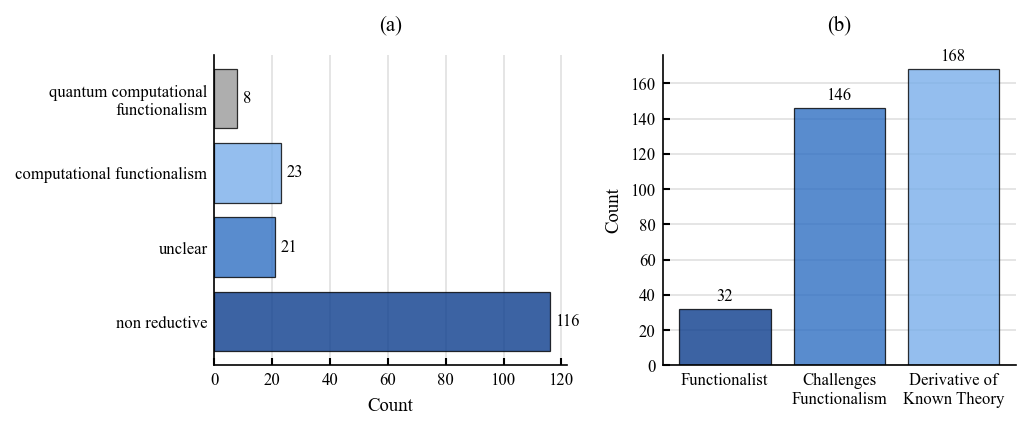

In [42]:
# Bar chart of theory types and functionalism
fig, axes = plt.subplots(1, 2, figsize=(7, 3))

# Theory type distribution

def _format_type_label(label: str) -> str:
    # Replace underscores and wrap long labels to two rows.
    text = str(label).replace('_', ' ').strip()
    words = text.split()
    if len(words) <= 2:
        return text
    return ' '.join(words[:2]) + '\n' + ' '.join(words[2:])

types = list(theory_types.keys())
types_display = [_format_type_label(t) for t in types]
counts = list(theory_types.values())
bar_colors = sns.color_palette(BLUE_GRAY_RAMP, n_colors=max(len(types), 1))
axes[0].set_axisbelow(True)
axes[0].barh(types_display, 
             counts, 
             color=bar_colors[:len(types)], 
             alpha=0.8, 
             edgecolor='black'
             )
axes[0].set_xlabel('Count')
axes[0].set_title('(a)')
axes[0].tick_params(axis='y', length=0)
axes[0].grid(axis='x', linestyle='-', alpha=0.7)
for i, (_, c) in enumerate(zip(types_display, counts)):
    axes[0].text(c + 2, i, str(c), 
                 va='center',
                 fontsize=8
                 )
# Functionalism analysis
func_data = {
    'Functionalist': functionalist_count,
    'Challenges\nFunctionalism': challenges_count,
    'Derivative of\nKnown Theory': derivative_count
}
func_colors = sns.color_palette(BLUE_GRAY_RAMP, n_colors=3)
axes[1].set_axisbelow(True)
axes[1].bar(func_data.keys(), func_data.values(),
            color=func_colors, 
            alpha=0.8, 
            edgecolor='black'
            )
axes[1].set_ylabel('Count')
axes[1].set_title('(b)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].tick_params(axis='x', length=0)
axes[1].grid(axis='y', linestyle='-', alpha=0.7)
for i, (k, v) in enumerate(func_data.items()):
    axes[1].text(i, v + 5, str(v), 
                 ha='center', 
                 fontsize=8
                 )
plt.tight_layout()
plt.savefig(output_dir / 'theory_classification.png', bbox_inches='tight')

**Figure 2.** Classification of AI-generated consciousness theories. (a) Distribution of theory types: count of theories assigned to each structural category (e.g., emergent, integrative, quantum, etc.). (b) Computational functionalism analysis: count of theories classified as purely functionalist, as challenging functionalism, or as derivative of a known theory family.

## 5.2 Calibrated + Manifold Novelty Analysis

An independent calibration-based novelty analysis that complements the fixed-threshold approach in Section 4:

- **Calibration baseline**: the empirical *known-vs-known* similarity distribution establishes what "normal" inter-theory similarity looks like within the existing literature.
- **Relative novelty (q05 criterion)**: AI theories whose maximum similarity to any known theory falls below the 5th percentile of known-known similarities are flagged as relatively novel.
- **Manifold novelty (kNN)**: the mean cosine distance from each AI theory to its *k* nearest known theories is compared against the q95 manifold boundary; theories beyond this boundary are labelled `OUTSIDE_MANIFOLD_NOVEL`.
- **Geometric diagnostic**: a known-anchored PCA projection with convex-hull overlay provides an interpretable 2D sanity check.

Each AI theory receives a **combined novelty score** (0.60 × relative novelty + 0.40 × manifold novelty) and one of three labels: `INSIDE_KNOWN_MANIFOLD`, `BOUNDARY_NOVEL_CANDIDATE`, or `OUTSIDE_MANIFOLD_NOVEL`.

In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# Section 5.2 — Bridge: map deduplicated theory spaces to alternative-analysis
# variable names.
#
# The Calibrated + Manifold Novelty analysis (Sections 5.2.1 onward) was
# developed with its own variable naming convention.  All underlying data is
# already available from Sections 1–4 of this notebook.  This cell creates the
# alias variables so that downstream cells run without modification.
# ─────────────────────────────────────────────────────────────────────────────

# --- theory lists (unique semantic clusters from Section 4.1) ---------------
known_names     = known_unique_names   # canonical names of unique known clusters
known_texts     = known_unique_texts   # representative texts for those clusters
known_emb       = known_unique_emb     # sentence embeddings  (n_known × d)
known_raw_texts = known_unique_texts   # alias used for word-count stats

ai_names        = ai_unique_names      # canonical names of unique AI clusters
ai_texts        = ai_unique_texts      # representative texts
ai_texts_raw    = ai_unique_texts      # alias used in downstream display cell
ai_emb          = ai_unique_emb        # sentence embeddings  (n_ai × d)

# --- per-cluster primary model name -----------------------------------------
# ai_unique_df['models'] stores all contributing models joined with ' || '.
# Use the first listed model as the representative label for each cluster.
ai_models = (
    ai_unique_df['models']
    .str.split(r'\s*\|\|\s*', regex=True)
    .str[0]
    .fillna('unknown')
    .tolist()
)

# --- word-count statistics (used by input inspection cell below) ------------
known_word_counts_raw = np.array([len(t.split()) for t in known_raw_texts])
known_word_counts     = np.array([len(t.split()) for t in known_texts])
ai_word_counts        = np.array([len(t.split()) for t in ai_texts])

# --- compatibility record list (used by display cell below) -----------------
ai_records = ai_unique_df.to_dict(orient='records')

print(f'Known theories (unique semantic clusters): {len(known_names)}')
print(f'AI theory clusters (unique semantic):      {len(ai_names)}')
print()
print(f'Known words  median / range: {np.median(known_word_counts):.0f}  '
      f'[{known_word_counts.min()}–{known_word_counts.max()}]')
print(f'AI words median / range:     {np.median(ai_word_counts):.0f}  '
      f'[{ai_word_counts.min()}–{ai_word_counts.max()}]')
print()
print('Embedding mode: reusing precomputed embeddings from Section 4.1 '
      '(all-MiniLM-L6-v2).')


Known theories (unique semantic clusters): 39
AI theory clusters (unique semantic):      67

Known words  median / range: 135  [111–159]
AI words median / range:     117  [103–126]

Embedding mode: reusing precomputed embeddings from Section 4.1 (all-MiniLM-L6-v2).


### 5.2.1 Input Data Inspection

Verify the exact theory text that will be used for the calibration analysis.  If descriptions appear too broad or noisy, edit the source CSV files and re-run from Section 5.2.

In [33]:
# Display AI-generated theory content used for the calibration analysis.
ai_review_df = pd.DataFrame({
    'ai_id': np.arange(1, len(ai_names) + 1),   # aligned with unique cluster count
    'model': ai_models,
    'theory_name': ai_names,
    'full_text_for_embedding': ai_texts,
})
ai_review_df['embedding_words'] = [len(t.split()) for t in ai_texts]

print('AI-generated theories to embed (review table):')
print(f'Rows: {len(ai_review_df)}')
print(f'Word count range: {ai_review_df["embedding_words"].min()} - {ai_review_df["embedding_words"].max()}')
display(ai_review_df.sample(min(1, len(ai_review_df))))

print('AI theory counts by model:')
display(ai_review_df['model'].value_counts().rename_axis('model').reset_index(name='count'))


AI-generated theories to embed (review table):
Rows: 67
Word count range: 103 - 126


,ai_id,model,theory_name,full_text_for_embedding,embedding_words
28,29,gpt-5.2,Causal Bottleneck Identity Theory (CBIT),CBIT proposes that consciousness emerges when ...,109


AI theory counts by model:


,model,count
0,gemini-3.1-pro-preview,18
1,gpt-5.2,16
2,deepseek-v3.2,13
3,claude-3.7-sonnet,9
4,perplexity-sonar-pro,6
5,llama-3.3-70b-instruct,5


In [34]:
# Reuse precomputed embeddings from Section 4.1 — no redundant encoding needed.
# known_emb and ai_emb were set in the bridge cell above.
from sklearn.metrics.pairwise import cosine_similarity

known_known_sim = cosine_similarity(known_emb, known_emb)
ai_known_sim    = similarity_matrix_combined   # shape (n_ai_unique, n_known_unique)

mask = ~np.eye(known_known_sim.shape[0], dtype=bool)
known_known_offdiag = known_known_sim[mask]

ai_max_sim   = ai_known_sim.max(axis=1)
ai_mean_sim  = ai_known_sim.mean(axis=1)
ai_min_sim   = ai_known_sim.min(axis=1)
ai_best_idx  = ai_known_sim.argmax(axis=1)
ai_best_family = [known_names[int(i)] for i in ai_best_idx]

print(f'Known-known similarity range: [{known_known_offdiag.min():.3f}, {known_known_offdiag.max():.3f}]')
print(f'AI-known max similarity range: [{ai_max_sim.min():.3f}, {ai_max_sim.max():.3f}]')


Known-known similarity range: [0.222, 0.783]
AI-known max similarity range: [0.539, 0.774]


In [35]:
# Relative novelty calibration against known-known baseline
kk_q05 = float(np.quantile(known_known_offdiag, 0.05))
kk_q50 = float(np.quantile(known_known_offdiag, 0.50))
kk_q95 = float(np.quantile(known_known_offdiag, 0.95))

# Percentile of each AI max similarity in known-known distribution
ai_max_percentile = np.array([np.mean(known_known_offdiag <= s) for s in ai_max_sim])

# Lower percentile => more novel relative to known-known similarities
relative_novel_by_max = ai_max_sim < kk_q05

print('Calibration quantiles (known-known off-diagonal):')
print(f'  q05={kk_q05:.3f}, q50={kk_q50:.3f}, q95={kk_q95:.3f}')
print(f'Relative max-sim novelty (< q05): {int(relative_novel_by_max.sum())}/{len(relative_novel_by_max)}')

Calibration quantiles (known-known off-diagonal):
  q05=0.327, q50=0.478, q95=0.630
Relative max-sim novelty (< q05): 0/67


In [36]:
# Manifold novelty via kNN distances in known embedding space
k = min(K_NEIGHBORS, max(1, len(known_names) - 1))
nn = NearestNeighbors(metric='cosine', n_neighbors=k + 1)
nn.fit(known_emb)

known_dists, _ = nn.kneighbors(known_emb, n_neighbors=k + 1)
known_knn_mean = known_dists[:, 1:].mean(axis=1)  # drop self-neighbor

ai_dists, _ = nn.kneighbors(ai_emb, n_neighbors=k)
ai_knn_mean = ai_dists.mean(axis=1)

manifold_thr95 = float(np.quantile(known_knn_mean, MANIFOLD_KNN_Q))
outside_manifold = ai_knn_mean > manifold_thr95

# z-score style distance for continuous signal
m_mu = float(np.mean(known_knn_mean))
m_sd = float(np.std(known_knn_mean) + 1e-9)
ai_knn_z = (ai_knn_mean - m_mu) / m_sd

print(f'kNN manifold threshold (q{int(MANIFOLD_KNN_Q*100)}): {manifold_thr95:.4f}')
print(f'Outside-manifold count: {int(outside_manifold.sum())}/{len(outside_manifold)}')

kNN manifold threshold (q95): 0.4531
Outside-manifold count: 1/67


Known-reference PCA span check:
  Known PC1 span=0.879, AI PC1 span=0.352
  Known PC2 span=0.921, AI PC2 span=0.463
Hull-corner known theories labeled: 8
Hull diagnostic plot saved to: results/test3_theory_generation/alt_reduced_space_hull_diagnostic.png


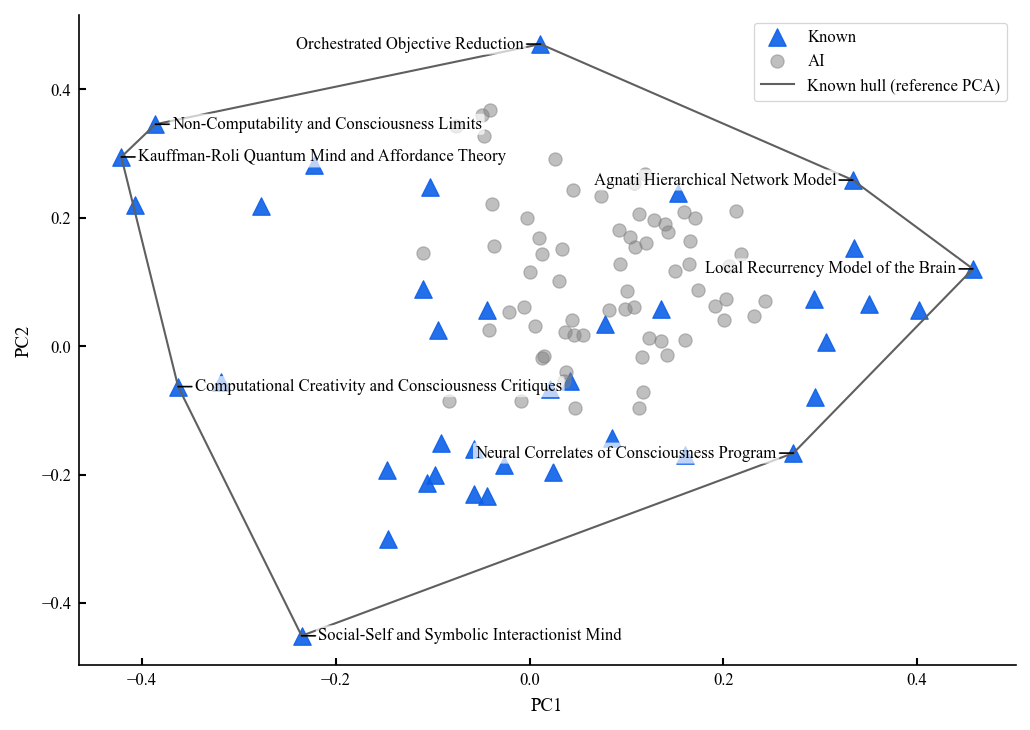

In [43]:
# 2D diagnostic: known-anchored PCA with labeled hull-corner known theories
hull_outside_2d = np.full(len(ai_names), np.nan)
hull_corner_indices = []

# Fit PCA on known only, then project AI into that space.
pca_known_ref = PCA(n_components=2, random_state=42)
known_xy_ref = pca_known_ref.fit_transform(known_emb)
ai_xy_ref = pca_known_ref.transform(ai_emb)

# Build hull in known-reference space and compute AI outside/inside status.
try:
    from scipy.spatial import ConvexHull
    from matplotlib.path import Path as MplPath

    if len(known_xy_ref) >= 3:
        hull = ConvexHull(known_xy_ref)
        hull_corner_indices = hull.vertices.tolist()
        hull_poly = known_xy_ref[hull_corner_indices]
        hull_path = MplPath(hull_poly)
        inside = hull_path.contains_points(ai_xy_ref)
        hull_outside_2d = (~inside).astype(float)
except Exception:
    pass


def _span(x):
    return float(np.max(x) - np.min(x))


print('Known-reference PCA span check:')
print(f"  Known PC1 span={_span(known_xy_ref[:, 0]):.3f}, AI PC1 span={_span(ai_xy_ref[:, 0]):.3f}")
print(f"  Known PC2 span={_span(known_xy_ref[:, 1]):.3f}, AI PC2 span={_span(ai_xy_ref[:, 1]):.3f}")
print(f'Hull-corner known theories labeled: {len(hull_corner_indices)}')

known_point_color = mpl.colors.to_hex(WHITE_SKY_CMAP(0.95))
ai_point_color = mpl.colors.to_hex(SKY_WHITE_GRAY_CMAP(1.00))
hull_line_color = THRESHOLD_COLOR
label_text_color = TEXT_COLOR

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(known_xy_ref[:, 0], 
           known_xy_ref[:, 1], 
           c=known_point_color, 
           marker='^', 
           s=70, 
           alpha=0.9, 
           label='Known'
           )
ax.scatter(ai_xy_ref[:, 0], 
           ai_xy_ref[:, 1], 
           c=ai_point_color, 
           marker='o', 
           s=40, 
           alpha=0.5, 
           label='AI'
           )
if len(hull_corner_indices) >= 3:
    hp = np.vstack([known_xy_ref[hull_corner_indices], known_xy_ref[hull_corner_indices[0]]])
    ax.plot(hp[:, 0], hp[:, 1],
            c=hull_line_color, 
            lw=1.0, 
            label='Known hull (reference PCA)')

    # Label only hull-corner known theories; auto-shift right-side labels left and draw connectors.
    x_mid = float(np.mean(known_xy_ref[:, 0]))
    for idx in hull_corner_indices:
        x, y = known_xy_ref[idx]
        label = str(known_names[idx])
        is_right_side = bool(x > x_mid)

        dx = -8 if is_right_side else 8
        ha = 'right' if is_right_side else 'left'

        ax.annotate(
            label,
            fontsize=8,
            xy=(x, y),
            xytext=(dx, 0),
            textcoords='offset points',
            ha=ha,
            va='center',
            color=label_text_color,
            bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.7),
            arrowprops=dict(
                arrowstyle='-',
                color=label_text_color,
                lw=0.8,
                shrinkA=0,
                shrinkB=0,
            ),
            clip_on=True,
        )

ax.set_title('')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend()

plt.tight_layout()
plt.savefig(output_dir / 'alt_reduced_space_hull_diagnostic.png', bbox_inches='tight')
print(f"Hull diagnostic plot saved to: {output_dir / 'alt_reduced_space_hull_diagnostic.png'}")
plt.show()

**Figure 3.** Known-reference PCA embedding of AI-generated and known consciousness theories (panel a). Principal components are fitted on the known-theory embeddings only; AI-generated theories are then projected into this fixed space. The convex hull of known theories marks the boundary of the established theoretical manifold. Labeled points at hull vertices identify the known theories that define the extremes of the known semantic space, with connector arrows for legibility.

In [38]:
# Multi-signal combination and labeling
comp_relative = 1.0 - ai_max_percentile
comp_manifold = np.clip((ai_knn_mean - np.quantile(known_knn_mean, 0.50)) / (manifold_thr95 - np.quantile(known_knn_mean, 0.50) + 1e-9), 0, 1)
combined_novelty = 0.60 * comp_relative + 0.40 * comp_manifold

labels = []
for rn, om in zip(relative_novel_by_max, outside_manifold):
    if rn and om:
        labels.append('OUTSIDE_MANIFOLD_NOVEL')
    elif rn or om:
        labels.append('BOUNDARY_NOVEL_CANDIDATE')
    else:
        labels.append('INSIDE_KNOWN_MANIFOLD')

alt_df = pd.DataFrame({
    'model': ai_models,
    'theory_name': ai_names,
    'closest_known_family': ai_best_family,
    'max_similarity_to_known': ai_max_sim,
    'mean_similarity_to_known': ai_mean_sim,
    'min_similarity_to_known': ai_min_sim,
    'legacy_derivative_rule_0p30': ai_max_sim > DERIVATIVE_SIMILARITY_THRESHOLD_LEGACY,
    'relative_max_similarity_percentile': ai_max_percentile,
    'relative_novel_by_max_q05': relative_novel_by_max,
    'knn_mean_distance_to_known': ai_knn_mean,
    'knn_distance_z': ai_knn_z,
    'outside_manifold_knn_q95': outside_manifold,
    'outside_known_hull_2d_pca': hull_outside_2d,
    'combined_novelty_score': combined_novelty,
    'alternative_novelty_label': labels,
}).sort_values(['combined_novelty_score', 'knn_mean_distance_to_known'], ascending=[False, False]).reset_index(drop=True)

alt_df.insert(0, 'alternative_rank', np.arange(1, len(alt_df) + 1))

alt_df.to_csv(output_dir / 'alternative_novelty_results.csv', index=False)

summary = alt_df['alternative_novelty_label'].value_counts().rename_axis('label').reset_index(name='count')
summary['rate'] = summary['count'] / len(alt_df)
summary.to_csv(output_dir / 'alternative_novelty_label_summary.csv', index=False)

calib = pd.DataFrame({
    'metric': ['known_known_q05', 'known_known_q50', 'known_known_q95', 'manifold_knn_q95'],
    'value': [kk_q05, kk_q50, kk_q95, manifold_thr95]
})
calib.to_csv(output_dir / 'alternative_calibration_values.csv', index=False)

print('Alternative novelty analysis complete.')
print(f"Saved: {output_dir / 'alternative_novelty_results.csv'}")
print(f"Saved: {output_dir / 'alternative_novelty_label_summary.csv'}")
print(f"Saved: {output_dir / 'alternative_calibration_values.csv'}")

display(summary)
display(alt_df.head(25))

Alternative novelty analysis complete.
Saved: results/test3_theory_generation/alternative_novelty_results.csv
Saved: results/test3_theory_generation/alternative_novelty_label_summary.csv
Saved: results/test3_theory_generation/alternative_calibration_values.csv


,label,count,rate
0,INSIDE_KNOWN_MANIFOLD,66,0.985075
1,BOUNDARY_NOVEL_CANDIDATE,1,0.014925


,alternative_rank,model,theory_name,closest_known_family,max_similarity_to_known,mean_similarity_to_known,min_similarity_to_known,legacy_derivative_rule_0p30,relative_max_similarity_percentile,relative_novel_by_max_q05,knn_mean_distance_to_known,knn_distance_z,outside_manifold_knn_q95,outside_known_hull_2d_pca,combined_novelty_score,alternative_novelty_label
0,1,gemini-3.1-pro-preview,Analog-Discrete Friction Theory (ADFT),Physicalist Structural Theories,0.539320,0.448050,0.275997,True,0.743590,False,0.467924,1.545716,True,0.0,0.553846,BOUNDARY_NOVEL_CANDIDATE
1,2,gpt-5.2,Dissipative Self-Metering Theory (DSMT),Free Energy Principle and Active Inference,0.580136,0.453378,0.291147,True,0.875843,False,0.442980,1.024593,False,0.0,0.404718,INSIDE_KNOWN_MANIFOLD
2,3,gpt-5.2,Intrinsic Manifold Metric Theory (IMMT),Physicalist Structural Theories,0.582578,0.479806,0.318775,True,0.875843,False,0.442390,1.012257,False,0.0,0.400642,INSIDE_KNOWN_MANIFOLD
3,4,gemini-3.1-pro-preview,Dimensional Residual Theory (DRT),Conscious Pilot Theory,0.583724,0.472090,0.291428,True,0.879892,False,0.438389,0.928680,False,0.0,0.370598,INSIDE_KNOWN_MANIFOLD
4,5,gpt-5.2,Gauge-Invariant Information Geometry Theory (G...,Dynamic Core Hypothesis,0.585651,0.484378,0.328149,True,0.881242,False,0.431633,0.787535,False,0.0,0.323153,INSIDE_KNOWN_MANIFOLD
5,6,gemini-3.1-pro-preview,Temporal Friction Theory (TFT),Dynamic Core Hypothesis,0.590681,0.466289,0.295278,True,0.889339,False,0.431245,0.779432,False,0.0,0.315617,INSIDE_KNOWN_MANIFOLD
6,7,gpt-5.2,Counterfactual Closure Theory (CCT),Free Energy Principle and Active Inference,0.605970,0.486057,0.352178,True,0.916329,False,0.426610,0.682581,False,0.0,0.267422,INSIDE_KNOWN_MANIFOLD
7,8,gemini-3.1-pro-preview,Ontological Friction Theory (OFT),Physicalist Structural Theories,0.617098,0.487579,0.380119,True,0.933873,False,0.424154,0.631278,False,0.0,0.239945,INSIDE_KNOWN_MANIFOLD
8,9,gpt-5.2,Thermodynamic Closure Theory Of Consciousness ...,Mind-Centered Structural Theories,0.593899,0.486842,0.316181,True,0.897436,False,0.418722,0.517785,False,0.0,0.224308,INSIDE_KNOWN_MANIFOLD
9,10,gemini-3.1-pro-preview,Topological Void Theory (TVT),Quantum Consciousness Theories,0.604844,0.493479,0.327618,True,0.913630,False,0.419429,0.532572,False,0.0,0.219477,INSIDE_KNOWN_MANIFOLD


### 5.2.2 Hypothesis-Focused Result Visualizations

Four complementary views of the AI creativity hypothesis problem:

- **View 1** (pie chart): share of theories per novelty label.
- **View 2** (box plot): model-level distributions of the combined novelty score.
- **View 3** (scatter): max-similarity vs. manifold-distance phase space, with a hypothesis-risk quadrant for theories that are simultaneously high-similarity *and* low-distance.
- **View 4** (heatmap): model × known-family attraction map using mean novelty scores.

*Interpretation:* a high share of `INSIDE_KNOWN_MANIFOLD` and a high hypothesis-risk rate support the AI creativity-limit hypothesis; model-level differences reveal whether this is a global or architecture-specific effect.

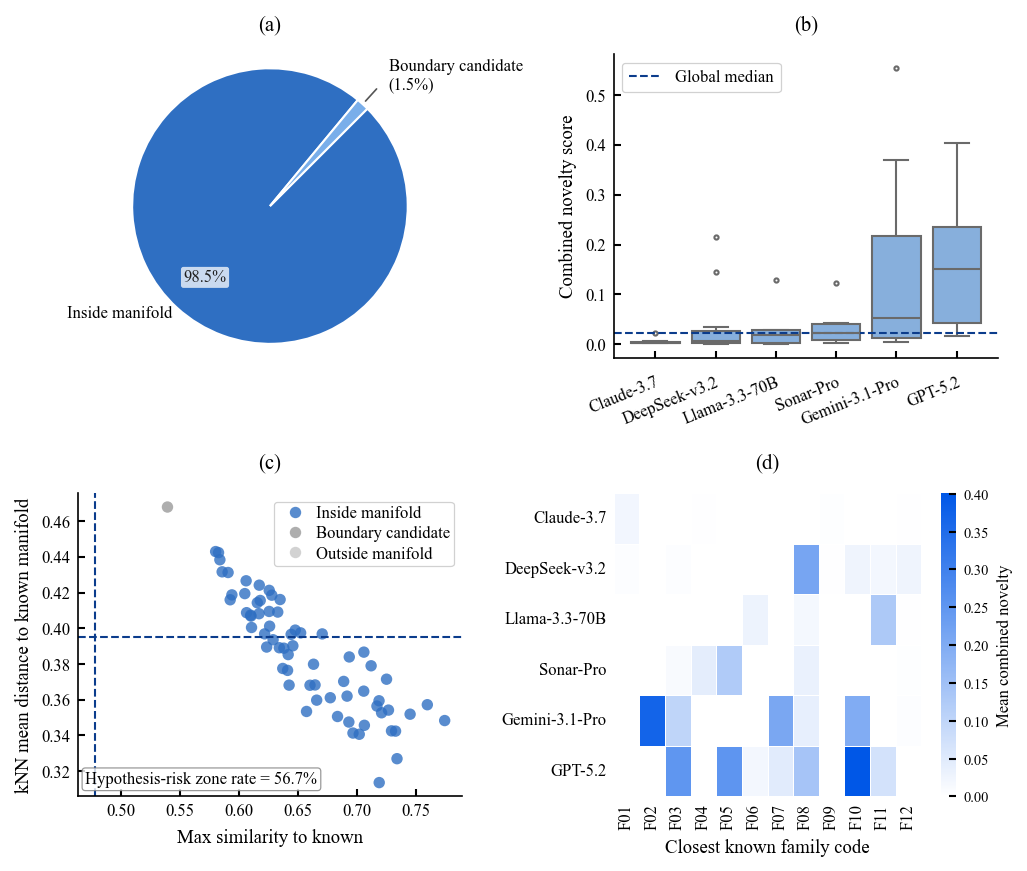

Family code mapping for View 4:


,family_code,closest_known_family
0,F01,Adaptive Resonance Theory of Consciousness
1,F02,Conscious Pilot Theory
2,F03,Dynamic Core Hypothesis
3,F04,Electromagnetic Field Theories
4,F05,Free Energy Principle and Active Inference
5,F06,Local Recurrent Processing Theory
6,F07,Microconsciousness Theory
7,F08,Mind-Centered Structural Theories
8,F09,Orchestrated Objective Reduction
9,F10,Physicalist Structural Theories


Saved:
results/test3_theory_generation/alternative_hypothesis_visualizations.png


In [44]:
# Four visual views of the AI creativity hypothesis problem (improved layout/readability)
viz_df = alt_df.copy()
inside_rate = float((viz_df['alternative_novelty_label'] == 'INSIDE_KNOWN_MANIFOLD').mean())
derivative_mask = (
    (viz_df['alternative_novelty_label'] == 'INSIDE_KNOWN_MANIFOLD')
    & (viz_df['max_similarity_to_known'] >= kk_q50)
    & (viz_df['knn_mean_distance_to_known'] <= np.quantile(known_knn_mean, 0.50))
)
derivative_rate = float(derivative_mask.mean())

label_order = [
    'INSIDE_KNOWN_MANIFOLD',
    'BOUNDARY_NOVEL_CANDIDATE',
    'OUTSIDE_MANIFOLD_NOVEL',
]

label_short = {
    'INSIDE_KNOWN_MANIFOLD': 'Inside manifold',
    'BOUNDARY_NOVEL_CANDIDATE': 'Boundary candidate',
    'OUTSIDE_MANIFOLD_NOVEL': 'Outside manifold',
}

model_short = {
    'perplexity-sonar-pro': 'Sonar-Pro',
    'claude-3.7-sonnet': 'Claude-3.7',
    'mistral-large': 'Mistral-L',
    'deepseek-v3.2': 'DeepSeek-v3.2',
    'llama-3.3-70b-instruct': 'Llama-3.3-70B',
    'gemini-3.1-pro-preview': 'Gemini-3.1-Pro',
    'gpt-5.2': 'GPT-5.2',
}


def _abbr_family(name: str, max_len: int = 30) -> str:
    txt = str(name)
    if len(txt) <= max_len:
        return txt
    words = [w for w in re.split(r'\s+', txt) if w and w.lower() not in {'of', 'and', 'the', 'to', 'for', 'in'}]
    if len(words) >= 3:
        acronym = ''.join(w[0].upper() for w in words if w[0].isalnum())
        if len(acronym) >= 3:
            return f'{acronym} ({txt[:16]}...)'
    return txt[: max_len - 3] + '...'


for col in ['model', 'alternative_novelty_label', 'closest_known_family']:
    viz_df[col] = viz_df[col].astype(str)

viz_df['model_short'] = viz_df['model'].map(model_short).fillna(viz_df['model'])
viz_df['label_short'] = viz_df['alternative_novelty_label'].map(label_short).fillna(viz_df['alternative_novelty_label'])
viz_df['family_short'] = viz_df['closest_known_family'].map(_abbr_family)

fig, axes = plt.subplots(2, 2, figsize=(7, 6))

# 1) Outcome distribution by novelty label (pie chart)
label_counts = (
    viz_df['alternative_novelty_label']
    .value_counts()
    .reindex(label_order, fill_value=0)
    .rename_axis('label')
    .reset_index(name='count')
)
label_counts['label_short'] = label_counts['label'].map(label_short)
label_counts['rate'] = label_counts['count'] / len(viz_df)

ax = axes[0, 0]
pie_color_map = {
    'INSIDE_KNOWN_MANIFOLD': BLUE_GRAY_RAMP[1],
    'BOUNDARY_NOVEL_CANDIDATE': BLUE_GRAY_RAMP[2],
    'OUTSIDE_MANIFOLD_NOVEL': BLUE_GRAY_RAMP[4],
}

# Plot only non-zero categories to avoid misleading extra labels.
pie_data = label_counts[label_counts['count'] > 0].copy()
pie_values = pie_data['count'].tolist()
pie_colors = [pie_color_map[k] for k in pie_data['label'].tolist()]
pie_labels = []
for _, row in pie_data.iterrows():
    short_lbl = row['label_short']
    if row['label'] == 'BOUNDARY_NOVEL_CANDIDATE':
        short_lbl = f"{short_lbl}\n({row['rate'] * 100:.1f}%)"
    pie_labels.append(short_lbl)


def _autopct_fmt(pct):
    return f'{pct:.1f}%' if pct >= 3 else ''

wedges, texts, autotexts = ax.pie(
    pie_values,
    labels=pie_labels,
    colors=pie_colors,
    autopct=_autopct_fmt,
    startangle=45,
    counterclock=False,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.0},
    textprops={'fontsize': 8},
    labeldistance=1.05,
    pctdistance=0.70,
)

for t in autotexts:
    t.set_color('#1f1f1f')
    t.set_fontsize(8)
    t.set_bbox(dict(facecolor='white', edgecolor='none', alpha=0.75, boxstyle='round,pad=0.15'))

# Add leader lines for tiny slices (<3%) and move those labels outward.
total = float(sum(pie_values)) if pie_values else 1.0
for wedge, txt, count in zip(wedges, texts, pie_values):
    pct = 100.0 * float(count) / total
    if pct < 3.0:
        ang = 0.5 * (wedge.theta1 + wedge.theta2)
        x = np.cos(np.deg2rad(ang))
        y = np.sin(np.deg2rad(ang))
        txt.set_position((1.28 * x, 1.28 * y))
        txt.set_ha('left' if x >= 0 else 'right')
        txt.set_va('center')
        ax.annotate(
            '',
            xy=(x, y),
            xytext=(1.18 * x, 1.18 * y),
            arrowprops=dict(arrowstyle='-', lw=0.8, color='#555555'),
        )

ax.set_title('(a)')
ax.axis('equal')

# 2) Model-level novelty score distributions
ax = axes[0, 1]
model_order = (
    viz_df.groupby('model_short')['combined_novelty_score']
    .median()
    .sort_values(ascending=True)
    .index
)
sns.boxplot(
    data=viz_df,
    x='model_short',
    y='combined_novelty_score',
    order=model_order,
    color=BLUE_GRAY_RAMP[2],
    fliersize=2,
    ax=ax,
)
ax.axhline(float(viz_df['combined_novelty_score'].median()), 
           ls='--', lw=1, c=BLUE_GRAY_RAMP[0], label='Global median')
ax.set_title('(b)')
ax.set_xlabel('')
ax.set_ylabel('Combined novelty score')
ax.tick_params(axis='x', labelrotation=22, pad=8)
for t in ax.get_xticklabels():
    t.set_horizontalalignment('right')
    t.set_verticalalignment('top')
    t.set_rotation_mode('anchor')
    t.set_fontsize(8)
ax.margins(x=0.05)
ax.legend(loc='upper left', framealpha=0.9)

# 3) Similarity-distance phase space with hypothesis-risk quadrant
ax = axes[1, 0]
phase_palette = {
    'INSIDE_KNOWN_MANIFOLD': BLUE_GRAY_RAMP[1],
    'BOUNDARY_NOVEL_CANDIDATE': BLUE_GRAY_RAMP[3],
    'OUTSIDE_MANIFOLD_NOVEL': BLUE_GRAY_RAMP[4],
}
sns.scatterplot(
    data=viz_df,
    x='max_similarity_to_known',
    y='knn_mean_distance_to_known',
    hue='alternative_novelty_label',
    hue_order=label_order,
    palette=phase_palette,
    alpha=0.8,
    s=30,
    edgecolor='none',
    ax=ax,
)
ax.axvline(kk_q50, ls='--', lw=1, c=BLUE_GRAY_RAMP[0])
ax.axhline(float(np.quantile(known_knn_mean, 0.50)), ls='--', lw=1, c=BLUE_GRAY_RAMP[0])
ax.set_title('(c)')
ax.set_xlabel('Max similarity to known')
ax.set_ylabel('kNN mean distance to known manifold')
ax.text(
    0.02,
    0.03,
    f'Hypothesis-risk zone rate = {derivative_rate:.1%}',
    fontsize=8,
    transform=ax.transAxes,
    ha='left',
    va='bottom',
    bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='gray', alpha=0.8),
)
# Final polish: compact legend labels and keep it at top-right as requested.
handles, _ = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=[label_short[x] for x in label_order],
    title=None,
    loc='upper right',
    framealpha=0.9,
    handletextpad=0.25,
    borderpad=0.25,
    labelspacing=0.25,
)

# 4) Conceptual attraction map: model x top known families
a = axes[1, 1]
top_families = viz_df['closest_known_family'].value_counts().head(12).index
heat_raw = (
    viz_df[viz_df['closest_known_family'].isin(top_families)]
    .pivot_table(
        index='model_short',
        columns='closest_known_family',
        values='combined_novelty_score',
        aggfunc='mean',
    )
)

family_code_map = {fam: f'F{i+1:02d}' for i, fam in enumerate(heat_raw.columns)}
heat_data = heat_raw.rename(columns=family_code_map)
heat_data = heat_data.loc[model_order]
# Missing combinations are treated as 0 and mapped to the lightest colormap color.
heat_data = heat_data.fillna(0.0)

sns.heatmap(
    heat_data,
    cmap=WHITE_SKY_CMAP,
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Mean combined novelty'},
    vmin=0.0,
    vmax=max(float(heat_data.to_numpy().max()), 1e-9),
    ax=a,
)
cbar = a.collections[0].colorbar
cbar.ax.tick_params(labelsize=7)
cbar.set_label('Mean combined novelty', fontsize=8)
a.set_title('(d)')
a.set_xlabel('Closest known family code')
a.set_ylabel('')
a.tick_params(axis='both', length=0)
for t in a.get_xticklabels():
    t.set_rotation(90)
    t.set_horizontalalignment('center')

plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.savefig(output_dir / 'alternative_hypothesis_visualizations.png', bbox_inches='tight')
plt.show()

family_map_df = pd.DataFrame(
    {'family_code': list(family_code_map.values()), 'closest_known_family': list(family_code_map.keys())}
)
print('Family code mapping for View 4:')
display(family_map_df)

print('Saved:')
print(output_dir / 'alternative_hypothesis_visualizations.png')

**Figure 4.** AI creativity hypothesis diagnostics across four complementary views. (a) Distribution of AI-generated theories by novelty label: inside the known manifold, boundary novel candidate, or outside the manifold. (b) Combined novelty score per model (boxplots sorted by median), with the global median shown as a dashed reference line. (c) Phase-space plot of maximum cosine similarity to known theories (x-axis) versus kNN mean distance to the known manifold (y-axis); dashed lines mark the median thresholds that define the hypothesis-risk zone, whose occupancy rate is annotated. (d) Heatmap of mean combined novelty score per model across the 12 most frequently assigned known theory families (family codes F01–F12 defined in the legend table below).

### Root Cause of the Large Model Differences in Combined Novelty

The combined novelty formula is:

**0.60** × `comp_relative` + **0.40** × `comp_manifold`

**Component 1 — `comp_relative` (60% weight): very small for everyone**

All models' theories fall into the 93rd–99th percentile of the known–known similarity distribution, meaning every AI theory is already highly similar to at least one known theory. This makes `comp_relative = 1 − percentile` only 0.009–0.061 across all models — practically negligible.

| Model | max_sim_percentile (median) | comp_relative |
|---|---|---|
| GPT-5.2 | 93.9% | 0.061 |
| Perplexity | 99.1% | 0.009 |

**Component 2 — `comp_manifold` (40% weight): the real driver**

```
comp_manifold = clip((ai_knn_mean - known_knn_q50) / (manifold_thr95 - known_knn_q50), 0, 1)
```

The known-kNN median ≈ 0.370, and the normalization range is only 0.370 → 0.439 (span of 0.069). The `clip` at 0 creates a sharp boundary — models whose kNN mean falls below the known median are forced to zero:

| Model | kNN mean (median) | vs known_knn_q50 | comp_manifold (implied) |
|---|---|---|---|
| GPT-5.2 | 0.400 | +0.030 above | 0.43 |
| Gemini-3.1-Pro | 0.395 | +0.025 above | 0.36 |
| Llama-3.3-70B | 0.383 | +0.013 above | 0.19 |
| DeepSeek-v3.2 | 0.362 | −0.008 below → **clipped** | ≈ 0 |
| Claude-3.7 | 0.349 | −0.021 below → **clipped** | 0 |
| Perplexity-Sonar | 0.349 | −0.021 below → **clipped** | 0 |
| Mistral-Large | 0.337 | −0.033 below → **clipped** | 0 |

**Three compounding effects make the gap look large:**

1. **Hard-floor amplification.** The `clip(…, 0, 1)` forces the lower half of models to exactly zero while the upper half retains a positive signal. A kNN-distance difference of only ~0.063 (GPT-5.2 vs Mistral) produces a ~30× difference in the final score (0.21 vs 0.007).

2. **Narrow normalization denominator.** The span `[known_knn_q50, manifold_thr95] = [0.370, 0.439]` is only 0.069 units wide. A real distance difference of 0.030 is mapped to 0.030/0.069 = **43% of the normalized scale**, greatly magnifying small absolute differences.

3. **Vocabulary-driven embedding drift.** GPT-5.2 and Gemini use physics- and mathematics-flavored terminology ("Gauge Invariance", "Dissipative Self-Metering", "Manifold Metric") that places their theories further from the philosophy-of-mind corpus used for calibration, inflating kNN distances independently of genuine conceptual novelty.

**Conclusion.** The between-model spread in combined novelty is not strong evidence of meaningfully different creativity levels. It reflects that GPT-5.2 and Gemini sit slightly *above* the known-kNN-median threshold while Claude, Mistral, and Perplexity sit slightly *below* it, and the clipped normalization formula converts that small absolute gap (~0.03–0.06 in cosine distance) into a 5–30× score difference. This is a known sensitivity of clipped normalized scoring to the choice of baseline percentile, and should be noted as a methodological limitation when interpreting model-level comparisons.

**TODO:** Check interpretation of novelty metric. Smaller value in novelty metric means more novel. That might be confusing. Think about if it is better to use Mean combined similarity or 1 - similarity which converts similarity values so that 0 means not novel and 1 means novel.

## 6. Comprehensive Results

Aggregate all novelty dimensions — ontological classification, functionalism flags, derivative detection, semantic novelty scores, and literature-grounded novelty — into a single results table per AI theory.  The table is ranked by global novelty score and saved to CSV for use in the dissertation analysis chapter.

In [40]:
# Create results dataframe with explicit novelty diagnostics columns.
results = []

# Raw (non-deduplicated) global similarity profile for each AI theory.
ai_mean_similarity_raw = np.asarray(similarity_matrix).mean(axis=1)
ai_global_novelty_raw = 1.0 - ai_mean_similarity_raw

for i, theory in enumerate(ai_theories, 1):
    cont_novelty = float(theory['continuous_literature_novelty'])
    ungated_lit_novel = cont_novelty >= LITERATURE_NOVELTY_THRESHOLD

    results.append({
        'ID': f'T{i}',
        'Model': theory['model'],
        'Theory_Name': theory['theory_name'],
        'Theory_Type': theory['theory_type'],
        'Is_Functionalist': theory['functionalism_analysis']['is_functionalist'],
        'Most_Similar_To': theory['most_similar_known_theory'],
        'Similarity_Max_To_Known': theory['similarity_to_known'],
        'Similarity_Mean_To_Known': float(ai_mean_similarity_raw[i - 1]),
        'Global_Novelty_Score': float(ai_global_novelty_raw[i - 1]),
        'Likely_Derivative': theory['is_likely_derivative'],
        'Semantic_Novelty_Component': theory['semantic_novelty_component'],
        'Name_Repetition_Factor': theory['name_repetition_factor'],
        'Continuous_Literature_Novelty': cont_novelty,
        'Novel_Literature_Grounded': theory['is_literature_novel'],
        'Novel_Literature_Continuous_Only': bool(ungated_lit_novel),
        'Novel_Non_Functionalist': (
            not theory['functionalism_analysis']['is_functionalist']
            and not theory['is_likely_derivative']
        )
    })

results_df = pd.DataFrame(results)

# Rank by global novelty score (higher is more novel).
results_df = results_df.sort_values(
    ['Global_Novelty_Score', 'Similarity_Max_To_Known'],
    ascending=[False, True]
).reset_index(drop=True)
results_df.insert(0, 'Global_Novelty_Rank', np.arange(1, len(results_df) + 1))

print("\n" + "=" * 110)
print("COMPREHENSIVE RESULTS: TEST 3 - CONSCIOUSNESS THEORY GENERATION")
print("=" * 110)
print(results_df.to_string(index=False))

# Save
results_df.to_csv(output_dir / 'test3_results.csv', index=False)
print(f"\nResults saved to: {output_dir / 'test3_results.csv'}")


COMPREHENSIVE RESULTS: TEST 3 - CONSCIOUSNESS THEORY GENERATION
 Global_Novelty_Rank   ID                  Model                                                    Theory_Name                         Theory_Type  Is_Functionalist                               Most_Similar_To  Similarity_Max_To_Known  Similarity_Mean_To_Known  Global_Novelty_Score  Likely_Derivative  Semantic_Novelty_Component  Name_Repetition_Factor  Continuous_Literature_Novelty  Novel_Literature_Grounded  Novel_Literature_Continuous_Only  Novel_Non_Functionalist
                   1  T23   perplexity-sonar-pro                           Resonant Binding Field Theory (RBFT)                       non_reductive             False                Electromagnetic Field Theories                 0.702568                  0.425536              0.574464               True                         0.0                0.707107                       0.323998                      False                             False               

In [41]:
# Summary with sanity checks for novelty metrics.
print("\n" + "=" * 110)
print("SUMMARY STATISTICS")
print("=" * 110)
print(f"Total theories analyzed: {len(ai_theories)}")
print(f"Computational functionalist: {functionalist_count} ({functionalist_count/len(ai_theories)*100:.1f}%)")
print(f"Challenge functionalism: {challenges_count} ({challenges_count/len(ai_theories)*100:.1f}%)")
print(f"Lenient derivative screen (> {DERIVATIVE_SIMILARITY_THRESHOLD:.2f}): {derivative_count} ({derivative_count/len(ai_theories)*100:.1f}%)")
print(f"Strict traceability (>= {STRICT_TRACEABILITY_THRESHOLD:.2f}): {strict_traceable_count} ({strict_traceable_count/len(ai_theories)*100:.1f}%)")
print(f"Novel non-functionalist: {int(results_df['Novel_Non_Functionalist'].sum())}")
print(f"Literature-grounded novel (gated): {int(results_df['Novel_Literature_Grounded'].sum())}")
print(f"Literature-grounded novel (continuous-only): {int(results_df['Novel_Literature_Continuous_Only'].sum())}")
print(f"Mean literature-grounded novelty score: {results_df['Continuous_Literature_Novelty'].mean():.3f}")

# Suspicious-pattern checks
semantic_zero_all = bool(np.isclose(results_df['Semantic_Novelty_Component'].to_numpy(), 0.0).all())
lit_novel_all_false = bool((results_df['Novel_Literature_Grounded'] == False).all())

print("\nSanity checks:")
print(f"  Semantic_Novelty_Component all zeros: {semantic_zero_all}")
print(f"  Novel_Literature_Grounded all False: {lit_novel_all_false}")

if semantic_zero_all:
    sim_min = float(results_df['Similarity_Max_To_Known'].min())
    sim_max = float(results_df['Similarity_Max_To_Known'].max())
    print("  Reason: semantic component is clip((threshold - max_similarity)/denom, 0, 1).")
    print(f"          Current max-sim range is [{sim_min:.3f}, {sim_max:.3f}] with lenient derivative threshold={DERIVATIVE_SIMILARITY_THRESHOLD:.2f}.")
    print("          If all max similarities exceed that threshold, the clipped value is 0 for all theories.")

if lit_novel_all_false:
    print("  Reason: current binary literature novelty is gated by NOT derivative.")
    print(f"          With the lenient derivative screen (> {DERIVATIVE_SIMILARITY_THRESHOLD:.2f}), if all theories exceed that threshold,")
    print("          this binary metric becomes all False even when continuous novelty scores still vary.")
    print(f"          Strict traceability is a separate reporting rule at >= {STRICT_TRACEABILITY_THRESHOLD:.2f}.")
    print("          Use continuous score and threshold sensitivity table for interpretation.")

print("\nConclusion: AI-generated theories predominantly remain within computational functionalism")
print(f"and all {len(ai_theories)} exceed the lenient derivative screen (> {DERIVATIVE_SIMILARITY_THRESHOLD:.2f}),")
print(f"while {strict_traceable_count}/{len(ai_theories)} meet the strict traceability threshold (>= {STRICT_TRACEABILITY_THRESHOLD:.2f}).")
print("\nAnalysis complete!")


SUMMARY STATISTICS
Total theories analyzed: 168
Computational functionalist: 32 (19.0%)
Challenge functionalism: 146 (86.9%)
Lenient derivative screen (> 0.30): 168 (100.0%)
Strict traceability (>= 0.70): 55 (32.7%)
Novel non-functionalist: 0
Literature-grounded novel (gated): 0
Literature-grounded novel (continuous-only): 46
Mean literature-grounded novelty score: 0.320

Sanity checks:
  Semantic_Novelty_Component all zeros: True
  Novel_Literature_Grounded all False: True
  Reason: semantic component is clip((threshold - max_similarity)/denom, 0, 1).
          Current max-sim range is [0.534, 0.800] with lenient derivative threshold=0.30.
          If all max similarities exceed that threshold, the clipped value is 0 for all theories.
  Reason: current binary literature novelty is gated by NOT derivative.
          With the lenient derivative screen (> 0.30), if all theories exceed that threshold,
          this binary metric becomes all False even when continuous novelty scores sti